# E3+++ LOSO 4-FOLD — Mỗi fold train 3 người, test 1 người chưa từng thấy

Notebook này chạy **Leave-One-Subject-Out (LOSO) 4 folds** trên 4 người: `hau`, `khoi`, `tai`, `vy`.

Mỗi outer fold:
- **TRAIN:** 3 người.
- **TEST:** toàn bộ dữ liệu của 1 người còn lại, hoàn toàn unseen.
- Người TEST **không được dùng để train, validation hay chọn epoch/checkpoint**.

Bên trong 3 người TRAIN, notebook dùng **inner subject-CV** để chọn số epoch. Sau đó model được fit lại trên đủ 3 người và mới đánh giá đúng 1 lần trên người TEST của outer fold.

Kết quả chính để báo cáo là **4-fold mean ± std** và **pooled out-of-fold accuracy/Macro-F1**. Notebook vẫn lưu `BEST_FOLD_BY_TEST.pt` theo yêu cầu lấy fold tốt nhất, nhưng metric của best fold **không được xem là accuracy tổng** vì đó là chọn fold sau khi đã nhìn outer-test.


Notebook cũng lưu **Train Loss & Validation Accuracy của từng outer fold** từ inner subject-CV để kiểm tra hội tụ/overfitting mà không dùng outer-test cho model selection.

**Train augmentation tay trái/tay phải:** mỗi mẫu train được dùng theo 2 phiên bản: bản gốc và bản **lật ngang toàn bộ video** (mirror). Với landmark đã normalize, mirror tương đương đảo dấu trục X; nếu input có 2 tay (126 features), hai slot tay cũng được đổi trái ↔ phải. Validation/test không được mirror để giữ đánh giá sạch.


In [1]:
import os
import re
import gc
import time
import json
import copy
import pickle
import random
import hashlib
import zipfile
import shutil
from pathlib import Path
from collections import Counter, defaultdict
from typing import Protocol

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import matplotlib
matplotlib.use("Agg")  # Kaggle không có GUI
import matplotlib.pyplot as plt

from IPython.display import display


In [2]:
# ============================================================
# 1) DATASET + LOADER + AUDIT
# ============================================================

PEOPLE = ("hau", "khoi", "tai", "vy")
SEQ_LEN = 45
VALID_FEATURE_DIMS = (63, 126)  # 1 tay hoặc 2 tay, mỗi tay 21 landmarks x 3

# Kaggle thường mount dataset ở /kaggle/input/<slug>/...
_DATA_CANDIDATES = [
    Path("/kaggle/input/vietnamese-sign-language-alphabet/landmarks/landmarks/raw"),
    Path("/kaggle/input/datasets/hauuto/vietnamese-sign-language-alphabet/landmarks/landmarks/raw"),
]

LANDMARK_DIR = next((p for p in _DATA_CANDIDATES if p.exists()), _DATA_CANDIDATES[0])

# Nếu Kaggle thay đổi mount path, tự tìm thư mục landmarks/raw.
if not LANDMARK_DIR.exists() and Path("/kaggle/input").exists():
    found = list(Path("/kaggle/input").glob("**/landmarks/raw"))
    if found:
        LANDMARK_DIR = found[0]

print("LANDMARK_DIR =", LANDMARK_DIR)

# code có thể chứa chữ/số/_; person là chuỗi chữ; block A/B; seq là số.
FNAME_RE = re.compile(r"^(?P<code>[a-z0-9_]+)_(?P<person>[a-z]+)_(?P<block>[AB])_(?P<seq>\d+)\.npy$")


def load_all_landmarks():
    """Đọc toàn bộ landmark .npy và kiểm tra format trước khi train."""
    if not LANDMARK_DIR.exists():
        raise FileNotFoundError(
            f"Không tìm thấy LANDMARK_DIR: {LANDMARK_DIR}\n"
            "Hãy Add Data -> vietnamese-sign-language-alphabet vào notebook Kaggle."
        )

    files = sorted(LANDMARK_DIR.glob("*/*.npy"))
    if not files:
        raise FileNotFoundError(f"Không có file .npy trong {LANDMARK_DIR}")

    records = []
    bad_names = []
    bad_arrays = []

    for f in files:
        m = FNAME_RE.match(f.name)
        if not m:
            bad_names.append(f.name)
            continue

        code_name = m.group("code")
        person = m.group("person")
        block = m.group("block")
        seq = int(m.group("seq"))

        arr = np.asarray(np.load(f), dtype=np.float32)
        if arr.ndim != 2 or arr.shape[0] != SEQ_LEN or arr.shape[1] not in VALID_FEATURE_DIMS:
            bad_arrays.append((f.name, tuple(arr.shape)))
            continue
        if not np.isfinite(arr).all():
            bad_arrays.append((f.name, "NaN/Inf"))
            continue

        records.append({
            "code": code_name,
            "person": person,
            "block": block,
            "seq": seq,
            "arr": arr,
            "path": str(f),
        })

    if bad_names:
        print(f"CẢNH BÁO: bỏ {len(bad_names)} file do tên không đúng quy ước. Ví dụ: {bad_names[:5]}")
    if bad_arrays:
        print(f"CẢNH BÁO: bỏ {len(bad_arrays)} file do shape/giá trị không hợp lệ. Ví dụ: {bad_arrays[:5]}")

    if not records:
        raise RuntimeError("Không đọc được sample hợp lệ nào.")

    shapes = sorted(set(tuple(r["arr"].shape) for r in records))
    if len(shapes) != 1:
        raise ValueError(
            f"Dataset có nhiều shape khác nhau {shapes}; không thể np.stack trực tiếp. "
            "Cần xử lý thống nhất số tay trước khi train."
        )

    return records, files


def audit_dataset(records, all_files):
    """In thống kê và kiểm tra exact duplicate giữa các person."""
    print("=" * 72)
    print("DATA AUDIT")
    print("=" * 72)
    print(f"Tổng file .npy tìm thấy : {len(all_files)}")
    print(f"Sample hợp lệ đọc được : {len(records)}")
    print(f"Shape                  : {records[0]['arr'].shape}")
    print(f"Số class               : {len(set(r['code'] for r in records))}")
    print("Theo person             :", dict(Counter(r["person"] for r in records)))
    print("Theo block              :", dict(Counter(r["block"] for r in records)))

    df = pd.DataFrame({
        "person": [r["person"] for r in records],
        "class": [r["code"] for r in records],
        "block": [r["block"] for r in records],
        "seq": [r["seq"] for r in records],
    })

    class_person = pd.crosstab(df["class"], df["person"])
    print("\nSố sample theo class/person:")
    display(class_person)
    class_person.to_csv("E3_data_audit_class_person.csv")

    print("\nSố sample theo person/block:")
    person_block = pd.crosstab(df["person"], df["block"])
    display(person_block)
    person_block.to_csv("E3_data_audit_person_block.csv")

    # Exact duplicate: cùng bytes landmark nhưng xuất hiện ở nhiều person.
    dup = defaultdict(list)
    for r in records:
        h = hashlib.md5(np.ascontiguousarray(r["arr"]).tobytes()).hexdigest()
        dup[h].append((r["person"], r["code"], r["block"], r["seq"], r["path"]))

    cross_person_dup = [
        items for items in dup.values()
        if len({x[0] for x in items}) > 1
    ]
    print(f"\nExact duplicates giữa các person: {len(cross_person_dup)}")
    if cross_person_dup:
        print("CẢNH BÁO: có duplicate giữa người; 5 nhóm đầu:")
        for items in cross_person_dup[:5]:
            print(items)
    else:
        print("OK: không phát hiện exact duplicate giữa các person.")

    expected_people = set(PEOPLE)
    actual_people = set(df["person"].unique())
    if actual_people != expected_people:
        print(f"CẢNH BÁO person: expected={sorted(expected_people)}, actual={sorted(actual_people)}")

    return {
        "dataframe": df,
        "class_person": class_person,
        "cross_person_duplicates": cross_person_dup,
    }


LANDMARK_DIR = /kaggle/input/datasets/hauuto/vietnamese-sign-language-alphabet/landmarks/landmarks/raw


In [3]:
# ============================================================
# 2) MODEL E3+++ — DOMAIN-INVARIANT MOTION BI-LSTM
# ============================================================

class _GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = float(lambd)
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd=1.0):
    return _GradReverse.apply(x, lambd)


class DomainInvariantMotionBiLSTM(nn.Module):
    """
    Input: normalized landmark sequence (B, T, D), D=63 hoặc 126.

    Feature/frame:
      1) pose         : x_t
      2) velocity     : Δx_t
      3) acceleration : Δ²x_t
      4) unit-bone    : vector xương đã chuẩn hóa độ dài

    Encoder: projection -> multi-scale residual temporal conv -> Bi-LSTM
             -> attention + mean pooling -> embedding.

    Train-only auxiliary head:
      subject/domain classifier qua Gradient Reversal Layer (GRL).
      Mục tiêu là giảm thông tin đặc thù người thực hiện trong embedding.
    """
    PARENT = (0, 0, 1, 2, 3, 0, 5, 6, 7, 5, 9, 10, 11, 9, 13, 14, 15, 13, 17, 18, 19)

    def __init__(self, input_dim: int, proj_dim: int, hidden_dim: int,
                 num_layers: int, num_classes: int, num_domains: int,
                 dropout: float = 0.35):
        super().__init__()
        if input_dim % 63 != 0:
            raise ValueError(f"input_dim phải chia hết cho 63, got {input_dim}")

        self.input_dim = int(input_dim)
        self.n_hands = input_dim // 63
        self.num_domains = int(num_domains)

        self.proj = nn.Sequential(
            nn.Linear(input_dim * 4, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.30),
        )

        # Hai receptive fields khác nhau; vẫn rất nhẹ vì depthwise conv.
        self.dw3 = nn.Conv1d(proj_dim, proj_dim, kernel_size=3, padding=1, groups=proj_dim)
        self.dw5_d2 = nn.Conv1d(
            proj_dim, proj_dim, kernel_size=5, padding=4, dilation=2, groups=proj_dim
        )
        self.pw = nn.Conv1d(proj_dim, proj_dim, kernel_size=1)
        self.temporal_norm = nn.LayerNorm(proj_dim)
        self.temporal_drop = nn.Dropout(dropout * 0.25)

        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        out_dim = hidden_dim * 2
        self.out_norm = nn.LayerNorm(out_dim)
        self.attn = nn.Sequential(
            nn.Linear(out_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

        self.embed = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.class_head = nn.Linear(out_dim, num_classes)

        # Chỉ dùng lúc train. Ở inference không cần head này.
        self.domain_head = nn.Sequential(
            nn.Linear(out_dim, max(32, hidden_dim // 2)),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(max(32, hidden_dim // 2), num_domains),
        )

    def _unit_bone(self, x):
        B, T, D = x.shape
        pts = x.reshape(B, T, self.n_hands, 21, 3)
        parent = torch.as_tensor(self.PARENT, dtype=torch.long, device=x.device)
        bone = pts - pts[:, :, :, parent, :]
        norm = torch.linalg.vector_norm(bone, dim=-1, keepdim=True).clamp_min(1e-6)
        unit = bone / norm
        unit[:, :, :, 0, :] = 0.0
        return unit.reshape(B, T, D)

    def encode(self, x):
        dx = torch.cat((torch.zeros_like(x[:, :1]), x[:, 1:] - x[:, :-1]), dim=1)
        ddx = torch.cat((torch.zeros_like(dx[:, :1]), dx[:, 1:] - dx[:, :-1]), dim=1)
        unit_bone = self._unit_bone(x)

        z = torch.cat((x, dx, ddx, unit_bone), dim=-1)
        z = self.proj(z)

        zc = z.transpose(1, 2)
        local = torch.nn.functional.gelu(self.dw3(zc))
        broader = torch.nn.functional.gelu(self.dw5_d2(zc))
        conv = self.pw(0.5 * (local + broader))
        conv = self.temporal_drop(conv.transpose(1, 2))
        z = self.temporal_norm(z + conv)

        out, _ = self.lstm(z)
        out = self.out_norm(out)

        attn_w = torch.softmax(self.attn(out), dim=1)
        attn_pool = (out * attn_w).sum(dim=1)
        mean_pool = out.mean(dim=1)
        emb = self.embed(torch.cat((attn_pool, mean_pool), dim=1))
        return emb

    def forward(self, x, grl_lambda=0.0, return_domain=False):
        emb = self.encode(x)
        class_logits = self.class_head(emb)
        if return_domain:
            domain_logits = self.domain_head(grad_reverse(emb, grl_lambda))
            return class_logits, domain_logits
        return class_logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [4]:
# ============================================================
# 3) TRAINING CONFIG + INNER SUBJECT-CV + DANN + EMA + TTA
# ============================================================

PROJ_DIM = 96
HIDDEN_DIM = 96
NUM_LAYERS = 1
DROPOUT = 0.35
LR = 8e-4
INNER_MAX_EPOCHS = 100
BATCH_SIZE = 32

SEED = 42
INNER_PATIENCE = 18
NUM_WORKERS = 2
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
ENSEMBLE_SIZE = 1  # deploy: đúng 1 model

# Domain-adversarial strength. GRL tăng dần từ 0 -> DOMAIN_LAMBDA_MAX.
DOMAIN_LAMBDA_MAX = 0.15

# EMA giúp giảm variance mà không tăng latency inference.
EMA_DECAY = 0.995

USE_HAND_NORMALIZATION = True
USE_TRAIN_AUGMENT = True

# Mỗi sample TRAIN luôn có 2 phiên bản: gốc + lật ngang toàn bộ video.
# Validation/Test KHÔNG flip để metric phản ánh dữ liệu thật.
USE_HORIZONTAL_FLIP_AUGMENT = True
HFLIP_SWAP_HAND_SLOTS = True  # với D=126: đổi tay trái <-> tay phải sau khi mirror

AUG_ROTATE_DEG = 8.0
AUG_JITTER_STD = 0.007
AUG_TIME_WARP = 0.10
AUG_Z_SCALE = 0.10

# Accuracy-first. Nếu cần benchmark latency/deploy, đổi thành (1.0,)
TTA_GAMMAS = (1.0,)  # deploy: không TTA

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ARTIFACT_DIR = Path("E3PPP_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Normalization={USE_HAND_NORMALIZATION} | Augment={USE_TRAIN_AUGMENT}")
print(
    f"Horizontal flip pair={USE_HORIZONTAL_FLIP_AUGMENT} "
    f"| swap hand slots={HFLIP_SWAP_HAND_SLOTS}"
)
print(f"Deploy mode | Single model={ENSEMBLE_SIZE} | TTA={TTA_GAMMAS}")
print(f"DANN lambda max={DOMAIN_LAMBDA_MAX} | EMA decay={EMA_DECAY}")


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def normalize_hand_sequence_keep_motion(X: np.ndarray) -> np.ndarray:
    """Sequence-level wrist/scale normalization, giữ wrist trajectory."""
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 3 or X.shape[1] != SEQ_LEN or X.shape[2] not in VALID_FEATURE_DIMS:
        raise ValueError(f"Expected (N, {SEQ_LEN}, 63/126), got {X.shape}")

    N, T, D = X.shape
    n_hands = D // 63
    pts = X.reshape(N, T, n_hands, 21, 3).copy()
    out = np.zeros_like(pts, dtype=np.float32)
    eps = 1e-6
    palm_ids = np.array([5, 9, 13, 17], dtype=np.int64)

    for h in range(n_hands):
        hand = pts[:, :, h]
        wrist = hand[:, :, 0, :]
        local = hand - wrist[:, :, None, :]
        palm_radius = np.linalg.norm(local[:, :, palm_ids, :], axis=-1)
        frame_scale = np.median(palm_radius, axis=-1)
        valid = frame_scale > 1e-4

        for n in range(N):
            valid_idx = np.flatnonzero(valid[n])
            if len(valid_idx) == 0:
                continue
            anchor = wrist[n, valid_idx[0]].copy()
            seq_scale = max(float(np.median(frame_scale[n, valid_idx])), eps)
            out[n, valid_idx, h, 0, :] = (wrist[n, valid_idx] - anchor) / seq_scale
            out[n, valid_idx, h, 1:, :] = local[n, valid_idx, 1:, :] / seq_scale

    return out.reshape(N, T, D).astype(np.float32)


def _time_warp_tensor(x: torch.Tensor, gamma: float) -> torch.Tensor:
    """Warp trục thời gian bằng gamma cố định; dùng được cho augment và TTA."""
    T = x.shape[-2]
    u = torch.linspace(0.0, 1.0, T, dtype=x.dtype, device=x.device)
    pos = (u.clamp_min(1e-6).pow(float(gamma))) * (T - 1)
    pos[0] = 0.0
    pos[-1] = float(T - 1)
    left = torch.floor(pos).long()
    right = torch.clamp(left + 1, max=T - 1)
    w = (pos - left.to(pos.dtype))

    # x có thể (T,D) hoặc (B,T,D)
    if x.ndim == 2:
        return x[left] * (1.0 - w[:, None]) + x[right] * w[:, None]
    if x.ndim == 3:
        return x[:, left] * (1.0 - w[None, :, None]) + x[:, right] * w[None, :, None]
    raise ValueError(f"Unsupported x.ndim={x.ndim}")


def horizontal_flip_sequence(
    x: torch.Tensor,
    *,
    normalized: bool = USE_HAND_NORMALIZATION,
    swap_hand_slots: bool = HFLIP_SWAP_HAND_SLOTS,
) -> torch.Tensor:
    """
    Lật ngang TOÀN BỘ sequence, tương đương mirror video theo trục dọc.

    Input: (T, 63) hoặc (T, 126), mỗi landmark là (x, y, z).

    - Nếu dữ liệu đã qua normalize_hand_sequence_keep_motion(): x_mirror = -x.
    - Nếu chưa normalize (MediaPipe image coordinates): x_mirror = 1 - x.
      Hand/frame bị missing (toàn 0) vẫn giữ nguyên 0.
    - Với 2 tay (126 features), swap hai block 63 chiều để Left <-> Right.

    Đây là augmentation deterministic: mỗi mẫu train có đúng 1 bản gốc + 1 bản mirror.
    """
    if x.ndim != 2 or x.shape[1] not in VALID_FEATURE_DIMS:
        raise ValueError(f"Expected (T, 63/126), got {tuple(x.shape)}")

    out = x.clone()
    T, D = out.shape
    n_hands = D // 63
    pts = out.reshape(T, n_hands, 21, 3).clone()

    if normalized:
        # Missing landmarks đang là 0 nên -0 vẫn là 0.
        pts[..., 0] = -pts[..., 0]
    else:
        # Chỉ mirror hand/frame thật sự có landmark, tránh biến missing 0 thành 1.
        valid_hand = pts.abs().sum(dim=(-1, -2)) > 1e-7  # (T, n_hands)
        mirrored_x = 1.0 - pts[..., 0]
        pts[..., 0] = torch.where(valid_hand[..., None], mirrored_x, pts[..., 0])

    if n_hands == 2 and swap_hand_slots:
        pts = pts.flip(dims=[1])

    return pts.reshape(T, D)


def augment_sequence(x: torch.Tensor) -> torch.Tensor:
    x = x.clone()
    T, D = x.shape
    n_hands = D // 63

    if torch.rand(()) < 0.70:
        angle = (torch.rand(()) * 2.0 - 1.0) * np.deg2rad(AUG_ROTATE_DEG)
        c, s = torch.cos(angle), torch.sin(angle)
        pts = x.reshape(T, n_hands, 21, 3)
        xx = pts[..., 0].clone()
        yy = pts[..., 1].clone()
        pts[..., 0] = c * xx - s * yy
        pts[..., 1] = s * xx + c * yy
        x = pts.reshape(T, D)

    if torch.rand(()) < 0.80:
        frame_valid = (x.abs().sum(dim=1, keepdim=True) > 1e-7).to(x.dtype)
        x = x + torch.randn_like(x) * AUG_JITTER_STD * frame_valid

    # MediaPipe depth thường thay đổi theo camera/người; jitter nhẹ trục z.
    if torch.rand(()) < 0.50:
        pts = x.reshape(T, n_hands, 21, 3)
        z_scale = 1.0 + (torch.rand(()) * 2.0 - 1.0) * AUG_Z_SCALE
        pts[..., 2] = pts[..., 2] * z_scale
        x = pts.reshape(T, D)

    if torch.rand(()) < 0.60:
        gamma = 1.0 + float((torch.rand(()) * 2.0 - 1.0) * AUG_TIME_WARP)
        x = _time_warp_tensor(x, gamma)

    return x


class LandmarkDomainDataset(Dataset):
    def __init__(self, X, y, d=None, augment=False, include_horizontal_flip=False):
        self.X = torch.tensor(np.asarray(X), dtype=torch.float32)
        self.y = torch.tensor(np.asarray(y), dtype=torch.long)
        self.d = torch.full_like(self.y, -1) if d is None else torch.tensor(np.asarray(d), dtype=torch.long)
        self.augment = bool(augment)
        self.include_horizontal_flip = bool(include_horizontal_flip)
        self.base_len = len(self.y)

    def __len__(self):
        # TRAIN: [N mẫu gốc] + [N mẫu mirror] => đúng 2N mẫu/epoch.
        return self.base_len * (2 if self.include_horizontal_flip else 1)

    def __getitem__(self, idx):
        is_flipped = self.include_horizontal_flip and idx >= self.base_len
        base_idx = idx % self.base_len

        x = self.X[base_idx]
        if is_flipped:
            x = horizontal_flip_sequence(
                x,
                normalized=USE_HAND_NORMALIZATION,
                swap_hand_slots=HFLIP_SWAP_HAND_SLOTS,
            )

        # Các augment ngẫu nhiên hiện có vẫn chạy trên cả bản gốc và bản mirror.
        if self.augment:
            x = augment_sequence(x)

        return x, self.y[base_idx], self.d[base_idx]


@torch.no_grad()
def _ema_update(ema_model, model, decay, step):
    # Warmup EMA để tránh model init chi phối quá lâu.
    d = min(float(decay), (1.0 + step) / (10.0 + step))
    for ema_p, p in zip(ema_model.parameters(), model.parameters()):
        ema_p.mul_(d).add_(p, alpha=1.0 - d)
    for ema_b, b in zip(ema_model.buffers(), model.buffers()):
        ema_b.copy_(b)


def _grl_schedule(progress, max_lambda=DOMAIN_LAMBDA_MAX):
    # Classic smooth DANN schedule, scale xuống max_lambda.
    p = float(np.clip(progress, 0.0, 1.0))
    return float(max_lambda * (2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0))


def _select_epoch_from_inner(inner):
    """
    Chọn 1 epoch chung bằng mean validation accuracy của cả 3 inner folds.
    Chỉ xét tới min common length để mỗi epoch đều có đủ 3 unseen-subject validations.
    Làm trơn 3 điểm để giảm nhiễu do mỗi val person chỉ có 160 mẫu.
    """
    common_len = min(len(x["history"]["val_acc"]) for x in inner)
    acc_mat = np.stack([np.asarray(x["history"]["val_acc"][:common_len], dtype=float) for x in inner])
    loss_mat = np.stack([np.asarray(x["history"]["val_loss"][:common_len], dtype=float) for x in inner])

    mean_acc = acc_mat.mean(axis=0)
    mean_loss = loss_mat.mean(axis=0)

    smooth = mean_acc.copy()
    if common_len >= 3:
        smooth[1:-1] = (mean_acc[:-2] + mean_acc[1:-1] + mean_acc[2:]) / 3.0

    best_score = smooth.max()
    candidates = np.flatnonzero(np.isclose(smooth, best_score, atol=1e-12))
    if len(candidates) > 1:
        # tie-break bằng validation loss trung bình
        best_idx = candidates[np.argmin(mean_loss[candidates])]
    else:
        best_idx = int(candidates[0])

    return int(best_idx + 1), {
        "common_len": int(common_len),
        "mean_val_acc": mean_acc.tolist(),
        "smooth_mean_val_acc": smooth.tolist(),
        "mean_val_loss": mean_loss.tolist(),
    }


class E3TriplePlusStrategy:
    def prepare_input(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float32)
        return normalize_hand_sequence_keep_motion(X) if USE_HAND_NORMALIZATION else X

    def _make_loader(self, X, y, d, shuffle, seed, augment=False):
        # Chỉ loader TRAIN (augment=True) mới được nhân đôi gốc + mirror.
        # Validation/test giữ nguyên để tránh leakage/metric bị thay đổi.
        ds = LandmarkDomainDataset(
            X, y, d=d, augment=augment,
            include_horizontal_flip=(augment and USE_HORIZONTAL_FLIP_AUGMENT),
        )
        generator = torch.Generator()
        generator.manual_seed(seed)
        return DataLoader(
            ds, batch_size=BATCH_SIZE, shuffle=shuffle,
            num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"),
            generator=generator if shuffle else None,
            persistent_workers=(NUM_WORKERS > 0),
        )

    def _new_model(self, input_dim, num_classes, num_domains):
        return DomainInvariantMotionBiLSTM(
            input_dim=input_dim, proj_dim=PROJ_DIM, hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS, num_classes=num_classes,
            num_domains=num_domains, dropout=DROPOUT,
        ).to(DEVICE)

    @staticmethod
    def _class_criterion():
        return nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    @staticmethod
    def _domain_criterion():
        return nn.CrossEntropyLoss()

    def _run_train_epoch(self, model, ema_model, loader, class_criterion, domain_criterion,
                         optimizer, epoch, max_epochs, global_step):
        model.train()
        loss_sum = 0.0
        class_loss_sum = 0.0
        domain_loss_sum = 0.0
        correct = 0
        domain_correct = 0
        total = 0

        for batch_idx, (xb, yb, db) in enumerate(loader):
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            db = db.to(DEVICE, non_blocking=True)

            progress = ((epoch - 1) + (batch_idx + 1) / max(len(loader), 1)) / max(max_epochs, 1)
            grl_lambda = _grl_schedule(progress)

            optimizer.zero_grad(set_to_none=True)
            logits, domain_logits = model(xb, grl_lambda=grl_lambda, return_domain=True)
            class_loss = class_criterion(logits, yb)
            domain_loss = domain_criterion(domain_logits, db)
            loss = class_loss + domain_loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            global_step += 1
            _ema_update(ema_model, model, EMA_DECAY, global_step)

            bs = xb.size(0)
            loss_sum += loss.item() * bs
            class_loss_sum += class_loss.item() * bs
            domain_loss_sum += domain_loss.item() * bs
            correct += (logits.argmax(1) == yb).sum().item()
            domain_correct += (domain_logits.argmax(1) == db).sum().item()
            total += bs

        return {
            "loss": loss_sum / max(total, 1),
            "class_loss": class_loss_sum / max(total, 1),
            "domain_loss": domain_loss_sum / max(total, 1),
            "acc": correct / max(total, 1),
            "domain_acc": domain_correct / max(total, 1),
            "global_step": global_step,
        }

    def _run_eval(self, model, loader, criterion):
        model.eval()
        loss_sum = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb, _ in loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                logits = model(xb)
                loss = criterion(logits, yb)
                loss_sum += loss.item() * xb.size(0)
                correct += (logits.argmax(1) == yb).sum().item()
                total += xb.size(0)
        return loss_sum / max(total, 1), correct / max(total, 1)

    def _select_epoch_one_person(self, X, y_enc, groups, val_person, input_dim, num_classes, seed):
        idx_val = np.flatnonzero(groups == val_person)
        idx_train = np.flatnonzero(groups != val_person)
        train_people = sorted(np.unique(groups[idx_train]).tolist())
        domain_map = {p: i for i, p in enumerate(train_people)}
        d_train = np.array([domain_map[p] for p in groups[idx_train]], dtype=np.int64)

        train_loader = self._make_loader(
            X[idx_train], y_enc[idx_train], d_train, shuffle=True, seed=seed, augment=USE_TRAIN_AUGMENT
        )
        val_loader = self._make_loader(
            X[idx_val], y_enc[idx_val], None, shuffle=False, seed=seed, augment=False
        )

        set_seed(seed)
        model = self._new_model(input_dim, num_classes, num_domains=len(train_people))
        ema_model = copy.deepcopy(model).eval()
        for p in ema_model.parameters():
            p.requires_grad_(False)

        class_criterion = self._class_criterion()
        domain_criterion = self._domain_criterion()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)

        history = {
            "train_loss": [], "train_class_loss": [], "train_domain_loss": [],
            "train_acc": [], "train_domain_acc": [],
            "val_loss": [], "val_acc": [], "lr": []
        }
        best_epoch = 1
        best_acc = -1.0
        best_loss_at_best_acc = float("inf")
        patience = 0
        global_step = 0

        effective_train = len(idx_train) * (2 if USE_HORIZONTAL_FLIP_AUGMENT else 1)
        print(
            f"    inner val={val_person} | train={train_people} | "
            f"n_train_original={len(idx_train)} n_train_effective={effective_train} "
            f"n_val={len(idx_val)}"
        )
        for epoch in range(1, INNER_MAX_EPOCHS + 1):
            tr = self._run_train_epoch(
                model, ema_model, train_loader, class_criterion, domain_criterion,
                optimizer, epoch, INNER_MAX_EPOCHS, global_step
            )
            global_step = tr["global_step"]

            # Model selection dựa trên EMA model vì final inference cũng dùng EMA.
            va_loss, va_acc = self._run_eval(ema_model, val_loader, class_criterion)
            lr_now = optimizer.param_groups[0]["lr"]

            history["train_loss"].append(tr["loss"])
            history["train_class_loss"].append(tr["class_loss"])
            history["train_domain_loss"].append(tr["domain_loss"])
            history["train_acc"].append(tr["acc"])
            history["train_domain_acc"].append(tr["domain_acc"])
            history["val_loss"].append(va_loss)
            history["val_acc"].append(va_acc)
            history["lr"].append(lr_now)

            improved = (va_acc > best_acc + 1e-12) or (
                abs(va_acc - best_acc) <= 1e-12 and va_loss < best_loss_at_best_acc
            )
            if improved:
                best_acc = float(va_acc)
                best_loss_at_best_acc = float(va_loss)
                best_epoch = epoch
                patience = 0
            else:
                patience += 1

            scheduler.step()

            if epoch == 1 or epoch % 10 == 0 or patience >= INNER_PATIENCE:
                print(
                    f"      epoch {epoch:3d}/{INNER_MAX_EPOCHS} | "
                    f"train_acc={tr['acc']:.3f} domain_acc={tr['domain_acc']:.3f} | "
                    f"val_acc={va_acc:.3f} loss={va_loss:.4f} | best={best_epoch} ({best_acc:.3f})"
                )
            if patience >= INNER_PATIENCE:
                break

        model.to("cpu")
        ema_model.to("cpu")
        del model, ema_model, optimizer, scheduler, train_loader, val_loader
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

        return {
            "val_person": val_person,
            "train_people": train_people,
            "best_epoch": int(best_epoch),
            "best_val_acc": float(best_acc),
            "best_val_loss_at_best_acc": float(best_loss_at_best_acc),
            "history": history,
        }

    def train(self, X_train: np.ndarray, y_train: np.ndarray, groups: np.ndarray,
              fold_name: str, seed: int = SEED, checkpoint_path: Path | None = None):
        X_train = np.asarray(X_train, dtype=np.float32)
        y_train = np.asarray(y_train)
        groups = np.asarray(groups)

        le = LabelEncoder()
        y_enc = le.fit_transform(y_train)
        num_classes = len(le.classes_)
        input_dim = X_train.shape[2]
        people = sorted(np.unique(groups).tolist())
        if len(people) != 3:
            raise ValueError(f"{fold_name}: expected 3 outer-train people, got {people}")

        probe = self._new_model(input_dim, num_classes, num_domains=len(people))
        print(f"[{fold_name}] params={count_parameters(probe):,}")
        del probe
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

        # 1) Mỗi outer-train person làm unseen validation đúng 1 lần.
        inner = []
        for i, val_person in enumerate(people):
            inner.append(self._select_epoch_one_person(
                X_train, y_enc, groups, val_person, input_dim, num_classes,
                seed=seed + 100 * (i + 1),
            ))

        median_epoch = max(1, int(round(float(np.median([x["best_epoch"] for x in inner])))))
        final_epochs, epoch_selection = _select_epoch_from_inner(inner)
        print(
            f"[{fold_name}] inner best epochs={[x['best_epoch'] for x in inner]} | "
            f"median={median_epoch} | mean-curve selected={final_epochs}"
        )
        print(f"[{fold_name}] inner best accs={[round(x['best_val_acc'], 4) for x in inner]}")

        # 2) Final fit đủ 3 người + DANN. Inference dùng EMA weights.
        domain_map = {p: i for i, p in enumerate(people)}
        d_full = np.array([domain_map[p] for p in groups], dtype=np.int64)

        models = []
        state_dicts = []
        final_histories = []
        ensemble_seeds = []

        for ens_idx in range(ENSEMBLE_SIZE):
            ens_seed = seed + 1000 + ens_idx * 97
            ensemble_seeds.append(int(ens_seed))
            set_seed(ens_seed)

            loader = self._make_loader(
                X_train, y_enc, d_full, shuffle=True, seed=ens_seed, augment=USE_TRAIN_AUGMENT
            )
            model = self._new_model(input_dim, num_classes, num_domains=len(people))
            ema_model = copy.deepcopy(model).eval()
            for p in ema_model.parameters():
                p.requires_grad_(False)

            class_criterion = self._class_criterion()
            domain_criterion = self._domain_criterion()
            optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)
            hist = {
                "train_loss": [], "train_class_loss": [], "train_domain_loss": [],
                "train_acc": [], "train_domain_acc": [], "lr": []
            }
            global_step = 0

            print(f"[{fold_name}] FINAL member {ens_idx+1}/{ENSEMBLE_SIZE} seed={ens_seed}, epochs={final_epochs}")
            for epoch in range(1, final_epochs + 1):
                tr = self._run_train_epoch(
                    model, ema_model, loader, class_criterion, domain_criterion,
                    optimizer, epoch, final_epochs, global_step
                )
                global_step = tr["global_step"]
                for k in ["loss", "class_loss", "domain_loss", "acc", "domain_acc"]:
                    hist["train_" + k if not k.startswith("train_") else k] = hist.get("train_" + k, [])
                hist["train_loss"].append(tr["loss"])
                hist["train_class_loss"].append(tr["class_loss"])
                hist["train_domain_loss"].append(tr["domain_loss"])
                hist["train_acc"].append(tr["acc"])
                hist["train_domain_acc"].append(tr["domain_acc"])
                hist["lr"].append(optimizer.param_groups[0]["lr"])
                scheduler.step()

                if epoch == 1 or epoch % 10 == 0 or epoch == final_epochs:
                    print(
                        f"  member {ens_idx+1} epoch {epoch:3d}/{final_epochs} | "
                        f"loss={tr['loss']:.4f} cls_acc={tr['acc']:.3f} dom_acc={tr['domain_acc']:.3f}"
                    )

            ema_model.eval()
            models.append(ema_model)
            state_dicts.append(copy.deepcopy(ema_model.state_dict()))
            final_histories.append(hist)

            model.to("cpu")
            del model, optimizer, scheduler, loader
            gc.collect()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()

        if checkpoint_path is not None:
            checkpoint_path = Path(checkpoint_path)
            checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save({
                "model_state_dicts": state_dicts,
                "classes": le.classes_.tolist(),
                "input_dim": int(input_dim),
                "proj_dim": PROJ_DIM,
                "hidden_dim": HIDDEN_DIM,
                "num_layers": NUM_LAYERS,
                "dropout": DROPOUT,
                "model_name": "DomainInvariantMotionBiLSTM",
                "inner_results": [{k: v for k, v in x.items() if k != "history"} for x in inner],
                "epoch_selection": epoch_selection,
                "median_inner_epoch": int(median_epoch),
                "final_epochs": int(final_epochs),
                "ensemble_size": int(ENSEMBLE_SIZE),
                "ensemble_seeds": ensemble_seeds,
                "outer_train_people": people,
                "domain_map": domain_map,
                "domain_lambda_max": DOMAIN_LAMBDA_MAX,
                "ema_decay": EMA_DECAY,
                "tta_gammas": list(TTA_GAMMAS),
                "use_hand_normalization": bool(USE_HAND_NORMALIZATION),
                "use_train_augment": bool(USE_TRAIN_AUGMENT),
                "use_horizontal_flip_augment": bool(USE_HORIZONTAL_FLIP_AUGMENT),
                "hflip_swap_hand_slots": bool(HFLIP_SWAP_HAND_SLOTS),
                "train_pairing": "original + full-horizontal-mirror",
                "label_smoothing": LABEL_SMOOTHING,
                "weight_decay": WEIGHT_DECAY,
            }, checkpoint_path)

        return {
            "models": models,
            "le": le,
            "inner": inner,
            "epoch_selection": epoch_selection,
            "median_inner_epoch": median_epoch,
            "final_histories": final_histories,
            "input_dim": input_dim,
            "final_epochs": final_epochs,
            "ensemble_size": ENSEMBLE_SIZE,
            "ensemble_seeds": ensemble_seeds,
            "final_train_size": len(X_train),
            "final_train_size_effective": len(X_train) * (2 if USE_HORIZONTAL_FLIP_AUGMENT else 1),
            "horizontal_flip_augment": bool(USE_HORIZONTAL_FLIP_AUGMENT),
            "outer_train_people": people,
        }

    def _ensemble_logits(self, models, xb):
        all_logits = []
        for gamma in TTA_GAMMAS:
            x_view = xb if abs(gamma - 1.0) < 1e-12 else _time_warp_tensor(xb, gamma)
            for m in models:
                all_logits.append(m(x_view))
        return torch.stack(all_logits, dim=0).mean(dim=0)

    def predict(self, model_state, X_test: np.ndarray) -> np.ndarray:
        models = model_state["models"]
        le = model_state["le"]
        for model in models:
            model.eval()

        pred_ids = []
        X_test = np.asarray(X_test, dtype=np.float32)
        with torch.no_grad():
            for start in range(0, len(X_test), BATCH_SIZE):
                xb = torch.tensor(X_test[start:start+BATCH_SIZE], dtype=torch.float32, device=DEVICE)
                logits = self._ensemble_logits(models, xb)
                pred_ids.append(logits.argmax(dim=1).cpu().numpy())
        return le.inverse_transform(np.concatenate(pred_ids))

    def measure_latency(self, model_state, X_sample: np.ndarray) -> float:
        models = model_state["models"]
        for model in models:
            model.eval()
        x = torch.tensor(X_sample[:1], dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            for _ in range(5):
                _ = self._ensemble_logits(models, x)
        N = 30
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(N):
                _ = self._ensemble_logits(models, x)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        return (time.perf_counter() - t0) * 1000.0 / N


Device: cuda
Normalization=True | Augment=True
Horizontal flip pair=True | swap hand slots=True
Deploy mode | Single model=1 | TTA=(1.0,)
DANN lambda max=0.15 | EMA decay=0.995


In [5]:
# ============================================================
# 4) OUTER LOSO 4-FOLD — MỖI FOLD 3 TRAIN / 1 UNSEEN TEST
#    Nested subject-CV bên trong 3 train subjects để chọn epoch
# ============================================================

CV_SEED = 2026
CV_DIR = Path("E3PPP_LOSO_4FOLD_ARTIFACTS")
FOLD_DIR = CV_DIR / "fold_checkpoints"
CV_DIR.mkdir(exist_ok=True)
FOLD_DIR.mkdir(exist_ok=True)


def stack_records(rs):
    return (
        np.stack([r["arr"] for r in rs]).astype(np.float32),
        np.array([r["code"] for r in rs]),
        np.array([r["person"] for r in rs]),
    )


def verify_outer_fold(records, train_idx, test_idx, test_person):
    """Hard guard: outer-test subject tuyệt đối không lọt vào outer-train."""
    train_people = {records[i]["person"] for i in train_idx.tolist()}
    test_people = {records[i]["person"] for i in test_idx.tolist()}

    if test_people != {test_person}:
        raise RuntimeError(
            f"Fold test={test_person}: TEST phải chỉ chứa đúng subject này, nhận {sorted(test_people)}"
        )
    if test_person in train_people:
        raise RuntimeError(f"SUBJECT LEAKAGE: {test_person} xuất hiện trong TRAIN.")
    if set(train_idx.tolist()) & set(test_idx.tolist()):
        raise RuntimeError("SAMPLE LEAKAGE: TRAIN và TEST overlap.")

    train_classes = {records[i]["code"] for i in train_idx.tolist()}
    test_classes = {records[i]["code"] for i in test_idx.tolist()}
    missing = sorted(test_classes - train_classes)
    if missing:
        raise RuntimeError(
            f"Fold test={test_person}: có class chỉ xuất hiện ở TEST mà không có trong TRAIN: {missing}"
        )

    return tuple(sorted(train_people))


# ------------------------------------------------------------
# Load + audit toàn dataset đúng 1 lần
# ------------------------------------------------------------
records, all_files = load_all_landmarks()
audit = audit_dataset(records, all_files)

X_all_raw, y_all, groups_all = stack_records(records)
strategy = E3TriplePlusStrategy()
X_all = strategy.prepare_input(X_all_raw)

available_people = tuple(sorted(np.unique(groups_all).tolist()))
missing_people = sorted(set(PEOPLE) - set(available_people))
extra_people = sorted(set(available_people) - set(PEOPLE))
if missing_people or extra_people:
    raise RuntimeError(
        f"Dataset people không khớp PEOPLE={PEOPLE}. Missing={missing_people}, extra={extra_people}"
    )
if len(available_people) != 4:
    raise RuntimeError(f"LOSO 4-fold cần đúng 4 người, hiện có {available_people}")

print("\n" + "=" * 80)
print("LOSO 4-FOLD — OUTER CROSS-SUBJECT EVALUATION")
print("=" * 80)
print("People:", available_people)
print("Mỗi fold: 3 người train | 1 người test hoàn toàn unseen")
print("Epoch selection: INNER subject-CV chỉ trên 3 người outer-train")

fold_rows = []
oof_rows = []
fold_checkpoint_paths = {}
fold_training_meta = {}

for fold_no, test_person in enumerate(available_people, start=1):
    print("\n" + "#" * 80)
    print(f"OUTER FOLD {fold_no}/4 — UNSEEN TEST PERSON = {test_person}")
    print("#" * 80)

    test_idx = np.flatnonzero(groups_all == test_person)
    train_idx = np.flatnonzero(groups_all != test_person)
    train_people = verify_outer_fold(records, train_idx, test_idx, test_person)

    if len(train_people) != 3:
        raise RuntimeError(
            f"Fold test={test_person}: cần đúng 3 train people, nhận {train_people}"
        )

    print("Train people :", train_people)
    print("Test person  :", test_person)
    print("Train samples (original):", len(train_idx))
    print(
        "Train samples (effective with HFlip):",
        len(train_idx) * (2 if USE_HORIZONTAL_FLIP_AUGMENT else 1),
    )
    print("Test samples (no flip):", len(test_idx))
    print("Leakage check: PASS")

    fold_name = f"fold_{fold_no}_test_{test_person}"
    checkpoint_path = FOLD_DIR / f"{fold_name}.pt"
    fold_seed = CV_SEED + fold_no * 10000

    # QUAN TRỌNG:
    # strategy.train() chạy inner subject-CV trên đúng 3 outer-train people
    # để chọn số epoch. Outer-test person không tham gia bước chọn model.
    state = strategy.train(
        X_train=X_all[train_idx],
        y_train=y_all[train_idx],
        groups=groups_all[train_idx],
        fold_name=fold_name,
        seed=fold_seed,
        checkpoint_path=checkpoint_path,
    )

    y_true = y_all[test_idx]
    y_pred = strategy.predict(state, X_all[test_idx])

    fold_accuracy = float(np.mean(y_pred == y_true))
    fold_macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    fold_latency_ms = float(strategy.measure_latency(state, X_all[test_idx]))

    fold_rows.append({
        "fold": int(fold_no),
        "test_person": test_person,
        "train_people": ",".join(train_people),
        "train_samples": int(len(train_idx)),
        "test_samples": int(len(test_idx)),
        "accuracy": fold_accuracy,
        "accuracy_percent": fold_accuracy * 100.0,
        "macro_f1": fold_macro_f1,
        "macro_f1_percent": fold_macro_f1 * 100.0,
        "selected_epochs": int(state["final_epochs"]),
        "inner_best_epochs": ",".join(str(x["best_epoch"]) for x in state["inner"]),
        "inner_best_val_acc_mean": float(np.mean([x["best_val_acc"] for x in state["inner"]])),
        "latency_ms": fold_latency_ms,
        "checkpoint": checkpoint_path.name,
    })

    for dataset_idx, true_label, pred_label in zip(test_idx.tolist(), y_true.tolist(), y_pred.tolist()):
        r = records[dataset_idx]
        oof_rows.append({
            "fold": int(fold_no),
            "test_person": test_person,
            "dataset_index": int(dataset_idx),
            "class": r["code"],
            "block": r["block"],
            "seq": int(r["seq"]),
            "path": r["path"],
            "y_true": true_label,
            "y_pred": pred_label,
            "correct": bool(true_label == pred_label),
        })

    # Ghi thêm outer-fold metadata vào checkpoint đã lưu.
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    ckpt.update({
        "outer_fold": int(fold_no),
        "outer_test_person": test_person,
        "outer_train_people": list(train_people),
        "outer_test_accuracy": fold_accuracy,
        "outer_test_macro_f1": fold_macro_f1,
        "outer_test_samples": int(len(test_idx)),
        "evaluation_protocol": "nested LOSO: outer 3-train/1-test; inner subject-CV on outer-train only",
        "outer_test_used_for_epoch_selection": False,
        # Persist inner histories so training curves can be reproduced from checkpoint.
        "inner_training_histories": [
            {
                "val_person": str(x["val_person"]),
                "train_people": list(x["train_people"]),
                "best_epoch": int(x["best_epoch"]),
                "best_val_acc": float(x["best_val_acc"]),
                "best_val_loss_at_best_acc": float(x["best_val_loss_at_best_acc"]),
                "history": {k: list(v) for k, v in x["history"].items()},
            }
            for x in state["inner"]
        ],
    })
    torch.save(ckpt, checkpoint_path)

    fold_checkpoint_paths[test_person] = checkpoint_path

    # Lưu đầy đủ inner-CV history để vẽ Train Loss & Validation Accuracy
    # cho đúng outer fold này. Outer-test person KHÔNG tham gia các curve này.
    inner_history_rows = []
    inner_history_meta = []
    for inner_res in state["inner"]:
        h = inner_res["history"]
        inner_history_meta.append({
            "val_person": str(inner_res["val_person"]),
            "train_people": list(inner_res["train_people"]),
            "best_epoch": int(inner_res["best_epoch"]),
            "best_val_acc": float(inner_res["best_val_acc"]),
            "best_val_loss_at_best_acc": float(inner_res["best_val_loss_at_best_acc"]),
            "history": {k: list(v) for k, v in h.items()},
        })

        n_hist = len(h["val_acc"])
        for e in range(n_hist):
            inner_history_rows.append({
                "outer_fold": int(fold_no),
                "outer_test_person": str(test_person),
                "inner_val_person": str(inner_res["val_person"]),
                "epoch": int(e + 1),
                "train_loss": float(h["train_loss"][e]),
                "train_class_loss": float(h["train_class_loss"][e]),
                "train_domain_loss": float(h["train_domain_loss"][e]),
                "train_acc": float(h["train_acc"][e]),
                "train_domain_acc": float(h["train_domain_acc"][e]),
                "val_loss": float(h["val_loss"][e]),
                "val_acc": float(h["val_acc"][e]),
                "lr": float(h["lr"][e]),
            })

    history_csv_path = CV_DIR / f"{fold_name}_inner_trainloss_valacc.csv"
    pd.DataFrame(inner_history_rows).to_csv(history_csv_path, index=False)

    fold_training_meta[test_person] = {
        "fold": int(fold_no),
        "test_person": str(test_person),
        "train_people": list(train_people),
        "final_epochs": int(state["final_epochs"]),
        "inner_best_epochs": [int(x["best_epoch"]) for x in state["inner"]],
        "epoch_selection": copy.deepcopy(state["epoch_selection"]),
        "inner": inner_history_meta,
        "history_csv": str(history_csv_path),
    }

    print(
        f"OUTER TEST {test_person}: accuracy={fold_accuracy:.4f} "
        f"({fold_accuracy*100:.2f}%) | macro_f1={fold_macro_f1:.4f} | "
        f"selected_epochs={state['final_epochs']}"
    )

    # Giải phóng model của fold trước khi sang fold kế tiếp.
    for m in state["models"]:
        m.to("cpu")
    del state
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows).sort_values("fold").reset_index(drop=True)
oof_df = pd.DataFrame(oof_rows).sort_values(["fold", "dataset_index"]).reset_index(drop=True)

fold_df.to_csv(CV_DIR / "LOSO_4FOLD_metrics_by_fold.csv", index=False)
oof_df.to_csv(CV_DIR / "LOSO_4FOLD_out_of_fold_predictions.csv", index=False)

print("\n" + "=" * 80)
print("4 OUTER FOLDS HOÀN TẤT")
print("=" * 80)
display(fold_df)


DATA AUDIT
Tổng file .npy tìm thấy : 640
Sample hợp lệ đọc được : 640
Shape                  : (45, 63)
Số class               : 34
Theo person             : {'hau': 160, 'khoi': 160, 'tai': 160, 'vy': 160}
Theo block              : {'A': 320, 'B': 320}

Số sample theo class/person:


person,hau,khoi,tai,vy
class,,,,
a,4,4,4,4
aa,6,6,6,6
aw,6,6,6,6
b,4,4,4,4
c,4,4,4,4
d,4,4,4,4
dd,6,6,6,6
e,4,4,4,4
ee,6,6,6,6



Số sample theo person/block:


block,A,B
person,,
hau,80,80
khoi,80,80
tai,80,80
vy,80,80



Exact duplicates giữa các person: 0
OK: không phát hiện exact duplicate giữa các person.

LOSO 4-FOLD — OUTER CROSS-SUBJECT EVALUATION
People: ('hau', 'khoi', 'tai', 'vy')
Mỗi fold: 3 người train | 1 người test hoàn toàn unseen
Epoch selection: INNER subject-CV chỉ trên 3 người outer-train

################################################################################
OUTER FOLD 1/4 — UNSEEN TEST PERSON = hau
################################################################################
Train people : ('khoi', 'tai', 'vy')
Test person  : hau
Train samples (original): 480
Train samples (effective with HFlip): 960
Test samples (no flip): 160
Leakage check: PASS
[fold_1_test_hau] params=293,222
    inner val=khoi | train=['tai', 'vy'] | n_train_original=320 n_train_effective=640 n_val=160


...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


      epoch   1/100 | train_acc=0.227 domain_acc=0.578 | val_acc=0.494 loss=2.6841 | best=1 (0.494)
      epoch  10/100 | train_acc=0.959 domain_acc=0.566 | val_acc=0.631 loss=1.7666 | best=8 (0.650)
      epoch  20/100 | train_acc=0.972 domain_acc=0.548 | val_acc=0.631 loss=1.7684 | best=13 (0.656)
      epoch  30/100 | train_acc=0.995 domain_acc=0.481 | val_acc=0.681 loss=1.6748 | best=30 (0.681)
      epoch  40/100 | train_acc=0.997 domain_acc=0.494 | val_acc=0.700 loss=1.6208 | best=36 (0.719)
      epoch  50/100 | train_acc=0.997 domain_acc=0.445 | val_acc=0.713 loss=1.6485 | best=36 (0.719)
      epoch  54/100 | train_acc=0.997 domain_acc=0.455 | val_acc=0.706 loss=1.6375 | best=36 (0.719)
    inner val=khoi | train=['hau', 'tai'] | n_train_original=320 n_train_effective=640 n_val=160
      epoch   1/100 | train_acc=0.203 domain_acc=0.517 | val_acc=0.331 loss=2.6297 | best=1 (0.331)
      epoch  10/100 | train_acc=0.922 domain_acc=0.603 | val_acc=0.656 loss=1.3410 | best=6 (0.688

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


OUTER TEST vy: accuracy=0.8938 (89.38%) | macro_f1=0.8958 | selected_epochs=23

4 OUTER FOLDS HOÀN TẤT


,fold,test_person,train_people,train_samples,test_samples,accuracy,accuracy_percent,macro_f1,macro_f1_percent,selected_epochs,inner_best_epochs,inner_best_val_acc_mean,latency_ms,checkpoint
0,1,hau,"khoi,tai,vy",480,160,0.79375,79.375,0.776411,77.641076,23,"5,52,49",0.704167,2.386732,fold_1_test_hau.pt
1,2,khoi,"hau,tai,vy",480,160,0.70000,70.000,0.708849,70.884948,26,"20,17,38",0.783333,2.322549,fold_2_test_khoi.pt
2,3,tai,"hau,khoi,vy",480,160,0.69375,69.375,0.698893,69.889265,30,"23,12,43",0.800000,2.170462,fold_3_test_tai.pt
3,4,vy,"hau,khoi,tai",480,160,0.89375,89.375,0.895845,89.584543,23,"36,6,35",0.685417,2.199398,fold_4_test_vy.pt


In [6]:
# ============================================================
# 5) 4-FOLD CV SUMMARY + VISUALIZERS
# ============================================================

# ------------------------------------------------------------
# 5.1 Metrics đúng nghĩa cross-subject
# ------------------------------------------------------------
cv_mean_accuracy = float(fold_df["accuracy"].mean())
cv_std_accuracy = float(fold_df["accuracy"].std(ddof=1))
cv_mean_macro_f1 = float(fold_df["macro_f1"].mean())
cv_std_macro_f1 = float(fold_df["macro_f1"].std(ddof=1))

pooled_accuracy = float(np.mean(oof_df["y_true"].to_numpy() == oof_df["y_pred"].to_numpy()))
pooled_macro_f1 = float(
    f1_score(oof_df["y_true"], oof_df["y_pred"], average="macro", zero_division=0)
)

# Theo yêu cầu: lấy fold có outer-test Macro-F1 cao nhất.
# LƯU Ý: đây là post-hoc selection trên outer-test, nên KHÔNG dùng score của fold này
# làm estimate tổng quát hóa cuối cùng. Metric báo cáo chính vẫn là 4-fold CV ở trên.
best_row = fold_df.sort_values(
    ["macro_f1", "accuracy"], ascending=[False, False]
).iloc[0]
BEST_FOLD = int(best_row["fold"])
BEST_TEST_PERSON = str(best_row["test_person"])
BEST_FOLD_SOURCE_PATH = FOLD_DIR / str(best_row["checkpoint"])
BEST_FOLD_CHECKPOINT_PATH = CV_DIR / "BEST_FOLD_BY_TEST.pt"
shutil.copy2(BEST_FOLD_SOURCE_PATH, BEST_FOLD_CHECKPOINT_PATH)

summary = {
    "protocol": "4-fold Leave-One-Subject-Out (each outer fold: 3 train subjects, 1 completely unseen test subject)",
    "num_folds": 4,
    "people": list(available_people),
    "cv_mean_accuracy": cv_mean_accuracy,
    "cv_std_accuracy": cv_std_accuracy,
    "cv_mean_accuracy_percent": cv_mean_accuracy * 100.0,
    "cv_std_accuracy_percent": cv_std_accuracy * 100.0,
    "cv_mean_macro_f1": cv_mean_macro_f1,
    "cv_std_macro_f1": cv_std_macro_f1,
    "cv_mean_macro_f1_percent": cv_mean_macro_f1 * 100.0,
    "cv_std_macro_f1_percent": cv_std_macro_f1 * 100.0,
    "pooled_oof_accuracy": pooled_accuracy,
    "pooled_oof_accuracy_percent": pooled_accuracy * 100.0,
    "pooled_oof_macro_f1": pooled_macro_f1,
    "pooled_oof_macro_f1_percent": pooled_macro_f1 * 100.0,
    "best_fold_posthoc": BEST_FOLD,
    "best_fold_test_person": BEST_TEST_PERSON,
    "best_fold_accuracy": float(best_row["accuracy"]),
    "best_fold_macro_f1": float(best_row["macro_f1"]),
    "best_fold_checkpoint": BEST_FOLD_CHECKPOINT_PATH.name,
    "best_fold_warning": "Best fold is selected after seeing outer-test scores; do not report it as overall CV accuracy.",
    "outer_test_used_for_epoch_selection": False,
}

with open(CV_DIR / "LOSO_4FOLD_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
pd.DataFrame([summary]).to_csv(CV_DIR / "LOSO_4FOLD_summary.csv", index=False)

print("\n" + "=" * 80)
print("LOSO 4-FOLD — FINAL CROSS-SUBJECT RESULT")
print("=" * 80)
print(f"Accuracy mean ± std : {cv_mean_accuracy*100:.2f}% ± {cv_std_accuracy*100:.2f}%")
print(f"Macro-F1 mean ± std : {cv_mean_macro_f1*100:.2f}% ± {cv_std_macro_f1*100:.2f}%")
print(f"Pooled OOF accuracy : {pooled_accuracy*100:.2f}%")
print(f"Pooled OOF Macro-F1 : {pooled_macro_f1*100:.2f}%")
print()
print(
    f"Best fold (post-hoc): fold {BEST_FOLD}, test={BEST_TEST_PERSON}, "
    f"acc={float(best_row['accuracy'])*100:.2f}%, "
    f"macro_f1={float(best_row['macro_f1'])*100:.2f}%"
)
print("Best-fold checkpoint:", BEST_FOLD_CHECKPOINT_PATH)
print("NOTE: Không dùng best-fold score làm accuracy tổng. Hãy báo 4-fold mean/std hoặc pooled OOF.")

display(fold_df)
display(pd.DataFrame([summary]))

# ------------------------------------------------------------
# 5.2 Pooled out-of-fold classification report
# Mỗi sample chỉ được dự đoán ở fold mà subject của nó là unseen TEST.
# ------------------------------------------------------------
all_labels = sorted(np.unique(y_all).tolist())
report_dict = classification_report(
    oof_df["y_true"], oof_df["y_pred"], labels=all_labels,
    zero_division=0, output_dict=True,
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(CV_DIR / "LOSO_4FOLD_pooled_classification_report.csv")

print("\n=== Pooled out-of-fold classification report ===")
print(classification_report(
    oof_df["y_true"], oof_df["y_pred"], labels=all_labels, zero_division=0
))

# ------------------------------------------------------------
# 5.3 Confusion matrix — pooled OOF
# ------------------------------------------------------------
cm = confusion_matrix(oof_df["y_true"], oof_df["y_pred"], labels=all_labels)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, aspect="auto")
ax.set_title("LOSO 4-Fold — Pooled Out-of-Fold Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(np.arange(len(all_labels)))
ax.set_yticks(np.arange(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=90, fontsize=7)
ax.set_yticklabels(all_labels, fontsize=7)
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(CV_DIR / "LOSO_4FOLD_pooled_confusion_matrix.png", dpi=180)
plt.close(fig)

# ------------------------------------------------------------
# 5.4 Accuracy / Macro-F1 theo outer fold
# ------------------------------------------------------------
x = np.arange(len(fold_df))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, fold_df["accuracy"].to_numpy(), marker="o", label="Accuracy")
ax.plot(x, fold_df["macro_f1"].to_numpy(), marker="o", label="Macro-F1")
ax.axhline(cv_mean_accuracy, linestyle="--", label=f"Mean accuracy={cv_mean_accuracy:.3f}")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {r.fold}\nTest {r.test_person}" for r in fold_df.itertuples()])
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("LOSO 4-Fold — Unseen-Subject Performance")
ax.legend()
fig.tight_layout()
fig.savefig(CV_DIR / "LOSO_4FOLD_scores_by_fold.png", dpi=180)
plt.close(fig)



LOSO 4-FOLD — FINAL CROSS-SUBJECT RESULT
Accuracy mean ± std : 77.03% ± 9.41%
Macro-F1 mean ± std : 77.00% ± 9.07%
Pooled OOF accuracy : 77.03%
Pooled OOF Macro-F1 : 77.85%

Best fold (post-hoc): fold 4, test=vy, acc=89.38%, macro_f1=89.58%
Best-fold checkpoint: E3PPP_LOSO_4FOLD_ARTIFACTS/BEST_FOLD_BY_TEST.pt
NOTE: Không dùng best-fold score làm accuracy tổng. Hãy báo 4-fold mean/std hoặc pooled OOF.


,fold,test_person,train_people,train_samples,test_samples,accuracy,accuracy_percent,macro_f1,macro_f1_percent,selected_epochs,inner_best_epochs,inner_best_val_acc_mean,latency_ms,checkpoint
0,1,hau,"khoi,tai,vy",480,160,0.79375,79.375,0.776411,77.641076,23,"5,52,49",0.704167,2.386732,fold_1_test_hau.pt
1,2,khoi,"hau,tai,vy",480,160,0.70000,70.000,0.708849,70.884948,26,"20,17,38",0.783333,2.322549,fold_2_test_khoi.pt
2,3,tai,"hau,khoi,vy",480,160,0.69375,69.375,0.698893,69.889265,30,"23,12,43",0.800000,2.170462,fold_3_test_tai.pt
3,4,vy,"hau,khoi,tai",480,160,0.89375,89.375,0.895845,89.584543,23,"36,6,35",0.685417,2.199398,fold_4_test_vy.pt


,protocol,num_folds,people,cv_mean_accuracy,cv_std_accuracy,cv_mean_accuracy_percent,cv_std_accuracy_percent,cv_mean_macro_f1,cv_std_macro_f1,cv_mean_macro_f1_percent,...,pooled_oof_accuracy_percent,pooled_oof_macro_f1,pooled_oof_macro_f1_percent,best_fold_posthoc,best_fold_test_person,best_fold_accuracy,best_fold_macro_f1,best_fold_checkpoint,best_fold_warning,outer_test_used_for_epoch_selection
0,4-fold Leave-One-Subject-Out (each outer fold:...,4,"[hau, khoi, tai, vy]",0.770312,0.094148,77.03125,9.414846,0.77,0.09069,76.999958,...,77.03125,0.778547,77.854662,4,vy,0.89375,0.895845,BEST_FOLD_BY_TEST.pt,Best fold is selected after seeing outer-test ...,False



=== Pooled out-of-fold classification report ===
              precision    recall  f1-score   support

           a       1.00      0.94      0.97        16
          aa       0.91      0.83      0.87        24
          aw       0.85      0.96      0.90        24
           b       0.88      0.88      0.88        16
           c       0.87      0.81      0.84        16
           d       0.76      0.81      0.79        16
          dd       0.96      0.92      0.94        24
           e       0.94      1.00      0.97        16
          ee       1.00      0.96      0.98        24
           g       1.00      1.00      1.00        16
           h       0.86      0.75      0.80        16
           i       0.71      0.62      0.67        16
           k       0.78      0.88      0.82        16
           l       1.00      0.88      0.93        16
           m       0.89      1.00      0.94        16
           n       0.73      1.00      0.84        16
           o       0.80      0.

In [7]:
# ============================================================
# 6) EXPORT ZIP — LOSO 4-FOLD
# ============================================================

fold_lines = []
for r in fold_df.itertuples():
    fold_lines.append(
        f"Fold {r.fold}: train=[{r.train_people}] | test={r.test_person} | "
        f"acc={r.accuracy*100:.2f}% | macro_f1={r.macro_f1*100:.2f}% | "
        f"epochs={r.selected_epochs}"
    )

README = f"""E3+++ LOSO 4-FOLD — 3 TRAIN SUBJECTS / 1 UNSEEN TEST SUBJECT PER FOLD
============================================================================

PROTOCOL
--------
4-fold Leave-One-Subject-Out (LOSO) trên: {", ".join(available_people)}

Mỗi OUTER fold:
- 3 subjects dùng để train.
- 1 subject còn lại là TEST hoàn toàn unseen.
- Outer-test subject không tham gia train, validation hoặc chọn epoch.

MODEL SELECTION BÊN TRONG MỖI FOLD
----------------------------------
Trên 3 outer-train subjects, chạy inner subject-CV:
- lần lượt giữ 1/3 train subject làm validation;
- chọn số epoch từ các inner validation curves;
- fit lại model trên đủ 3 outer-train subjects;
- cuối cùng mới test đúng 1 lần trên outer-test subject.

4 OUTER FOLDS
-------------
{chr(10).join(fold_lines)}

CV RESULT — NÊN DÙNG ĐỂ BÁO CÁO
-------------------------------
Accuracy mean ± std : {cv_mean_accuracy*100:.2f}% ± {cv_std_accuracy*100:.2f}%
Macro-F1 mean ± std : {cv_mean_macro_f1*100:.2f}% ± {cv_std_macro_f1*100:.2f}%
Pooled OOF accuracy : {pooled_accuracy*100:.2f}%
Pooled OOF Macro-F1 : {pooled_macro_f1*100:.2f}%

BEST FOLD THEO OUTER-TEST — CHỈ THAM KHẢO / LƯU CHECKPOINT
----------------------------------------------------------
Fold        : {BEST_FOLD}
Test person : {BEST_TEST_PERSON}
Accuracy    : {float(best_row['accuracy'])*100:.2f}%
Macro-F1    : {float(best_row['macro_f1'])*100:.2f}%
Checkpoint  : {BEST_FOLD_CHECKPOINT_PATH.name}

CẢNH BÁO QUAN TRỌNG
-------------------
Best fold được chọn sau khi đã thấy score của 4 outer-test folds. Vì vậy không được
lấy accuracy của best fold làm accuracy chung của hệ thống. Làm vậy sẽ cherry-pick
và làm kết quả cao ảo. Metric đánh giá tổng quát hóa đúng là 4-fold mean/std hoặc
pooled out-of-fold metrics ở phía trên.

FILES
-----
LOSO_4FOLD_summary.csv/json
LOSO_4FOLD_metrics_by_fold.csv
LOSO_4FOLD_out_of_fold_predictions.csv
LOSO_4FOLD_pooled_classification_report.csv
LOSO_4FOLD_pooled_confusion_matrix.png
LOSO_4FOLD_scores_by_fold.png
fold_*_test_*_inner_trainloss_valacc.csv
EVAL_05_fold_*_trainloss_valacc.png
EVAL_05_all_folds_trainloss_valacc.png
BEST_FOLD_BY_TEST.pt
fold_checkpoints/fold_1_test_*.pt ... fold_4_test_*.pt
"""

with open(CV_DIR / "README.txt", "w", encoding="utf-8") as f:
    f.write(README)

zip_path = Path("E3PPP_LOSO_4FOLD_3TRAIN_1TEST.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(CV_DIR.rglob("*")):
        if p.is_file():
            zf.write(p, arcname=str(p.relative_to(CV_DIR)))

print("\n" + "=" * 80)
print("EXPORT HOÀN TẤT")
print("=" * 80)
print("Artifacts :", CV_DIR)
print("ZIP       :", zip_path)
print("Best fold :", BEST_FOLD_CHECKPOINT_PATH)
print(f"CV Acc    : {cv_mean_accuracy*100:.2f}% ± {cv_std_accuracy*100:.2f}%")
print(f"Pooled Acc: {pooled_accuracy*100:.2f}%")



EXPORT HOÀN TẤT
Artifacts : E3PPP_LOSO_4FOLD_ARTIFACTS
ZIP       : E3PPP_LOSO_4FOLD_3TRAIN_1TEST.zip
Best fold : E3PPP_LOSO_4FOLD_ARTIFACTS/BEST_FOLD_BY_TEST.pt
CV Acc    : 77.03% ± 9.41%
Pooled Acc: 77.03%


In [8]:
# ============================================================
# 7) LOAD BEST-FOLD CHECKPOINT & PREDICT — DEPLOY EXAMPLE
# ============================================================
# BEST_FOLD_BY_TEST.pt được lưu theo yêu cầu "lấy best trên 4 fold".
# Lưu ý: model này chỉ train trên 3/4 subjects của fold tương ứng.


def load_deploy_model(checkpoint_path=BEST_FOLD_CHECKPOINT_PATH, member_index=0):
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    state_dicts = ckpt.get("model_state_dicts")
    if not state_dicts:
        # backward compatibility nếu load checkpoint kiểu single state dict cũ
        single = ckpt.get("model_state_dict")
        if single is None:
            raise KeyError("Checkpoint không có model_state_dicts/model_state_dict")
        state_dicts = [single]

    if not (0 <= member_index < len(state_dicts)):
        raise IndexError(f"member_index={member_index}, ensemble size={len(state_dicts)}")

    num_domains = len(ckpt.get("domain_map", {}))
    if num_domains <= 0:
        num_domains = len(ckpt.get("outer_train_people", []))
    if num_domains <= 0:
        num_domains = 3

    model = DomainInvariantMotionBiLSTM(
        input_dim=ckpt["input_dim"],
        proj_dim=ckpt["proj_dim"],
        hidden_dim=ckpt["hidden_dim"],
        num_layers=ckpt["num_layers"],
        num_classes=len(ckpt["classes"]),
        num_domains=num_domains,
        dropout=ckpt["dropout"],
    )
    model.load_state_dict(state_dicts[member_index])
    model.eval()
    if hasattr(model, "lstm"):
        model.lstm.flatten_parameters()
    return model, ckpt


def predict_one_raw_sequence(raw_sequence, checkpoint_path=BEST_FOLD_CHECKPOINT_PATH, device=None):
    """raw_sequence shape: (45, 63) hoặc (45, 126)."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model, ckpt = load_deploy_model(checkpoint_path)
    model = model.to(device)

    x = np.asarray(raw_sequence, dtype=np.float32)[None, ...]
    if ckpt.get("use_hand_normalization", True):
        x = normalize_hand_sequence_keep_motion(x)

    xt = torch.tensor(x, dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = model(xt)
        probs = torch.softmax(logits, dim=1)[0]
        pred_id = int(probs.argmax().item())

    return {
        "class": ckpt["classes"][pred_id],
        "confidence": float(probs[pred_id].item()),
        "outer_fold": ckpt.get("outer_fold"),
        "outer_test_person": ckpt.get("outer_test_person"),
        "outer_train_people": ckpt.get("outer_train_people"),
    }


print("Deploy loader đã sẵn sàng.")
print("Checkpoint mặc định:", BEST_FOLD_CHECKPOINT_PATH)
print("Ví dụ: predict_one_raw_sequence(records[0]['arr'])")


Deploy loader đã sẵn sàng.
Checkpoint mặc định: E3PPP_LOSO_4FOLD_ARTIFACTS/BEST_FOLD_BY_TEST.pt
Ví dụ: predict_one_raw_sequence(records[0]['arr'])


## 8) ĐÁNH GIÁ TỔNG HỢP & VISUALIZATION

Phần này **không train lại model**. Nó dùng kết quả out-of-fold (OOF) của 4 fold ở trên để đánh giá khả năng tổng quát hóa sang **người chưa từng xuất hiện trong train**.

Các số chính cần dùng khi báo cáo là **4-fold mean ± std** và **pooled OOF metrics**. `BEST_FOLD_BY_TEST.pt` chỉ là fold tốt nhất sau khi đã nhìn kết quả test của cả 4 fold, vì vậy **không dùng score của best fold làm accuracy chung**.

Các biểu đồ bên dưới giúp nhìn 4 khía cạnh:
1. Độ ổn định giữa 4 người/fold.
2. Class nào dễ/khó đối với model.
3. Các cặp class model thường nhầm với nhau.
4. Class nào phụ thuộc mạnh vào từng người thực hiện.


In [9]:
# ============================================================
# 8.1 BẢNG ĐÁNH GIÁ TỔNG HỢP
# ============================================================
from IPython.display import display, Markdown

# Metric theo từng unseen subject
subject_rows = []
for person in available_people:
    part = oof_df[oof_df["test_person"] == person]
    acc = float((part["y_true"] == part["y_pred"]).mean())
    mf1 = float(f1_score(part["y_true"], part["y_pred"], average="macro", zero_division=0))
    subject_rows.append({
        "test_person": person,
        "samples": int(len(part)),
        "accuracy": acc,
        "accuracy_%": acc * 100.0,
        "macro_f1": mf1,
        "macro_f1_%": mf1 * 100.0,
    })
subject_eval_df = pd.DataFrame(subject_rows).sort_values("test_person").reset_index(drop=True)

# Metric theo class từ toàn bộ OOF predictions
class_eval_df = report_df.loc[all_labels, ["precision", "recall", "f1-score", "support"]].copy()
class_eval_df.index.name = "class"
class_eval_df = class_eval_df.reset_index().sort_values("f1-score").reset_index(drop=True)

best_subject_row = subject_eval_df.loc[subject_eval_df["accuracy"].idxmax()]
worst_subject_row = subject_eval_df.loc[subject_eval_df["accuracy"].idxmin()]
subject_gap = float(best_subject_row["accuracy"] - worst_subject_row["accuracy"])

weakest_classes = class_eval_df.head(5).copy()
strongest_classes = class_eval_df.tail(5).sort_values("f1-score", ascending=False).copy()

assessment_df = pd.DataFrame([{
    "CV Accuracy mean (%)": cv_mean_accuracy * 100.0,
    "CV Accuracy std (%)": cv_std_accuracy * 100.0,
    "CV Macro-F1 mean (%)": cv_mean_macro_f1 * 100.0,
    "CV Macro-F1 std (%)": cv_std_macro_f1 * 100.0,
    "Pooled OOF Accuracy (%)": pooled_accuracy * 100.0,
    "Pooled OOF Macro-F1 (%)": pooled_macro_f1 * 100.0,
    "Best unseen subject": str(best_subject_row["test_person"]),
    "Best subject accuracy (%)": float(best_subject_row["accuracy_%"]),
    "Hardest unseen subject": str(worst_subject_row["test_person"]),
    "Hardest subject accuracy (%)": float(worst_subject_row["accuracy_%"]),
    "Best-worst subject gap (%)": subject_gap * 100.0,
}])

print("=" * 90)
print("ĐÁNH GIÁ TỔNG HỢP — LOSO 4-FOLD")
print("=" * 90)
display(assessment_df.round(2))

print("\nHiệu năng trên từng người hoàn toàn unseen:")
display(subject_eval_df.round({"accuracy": 4, "accuracy_%": 2, "macro_f1": 4, "macro_f1_%": 2}))

print("\n5 class có F1 thấp nhất:")
display(weakest_classes.round(3))

print("\n5 class có F1 cao nhất:")
display(strongest_classes.round(3))

print("\nNHẬN XÉT TỰ ĐỘNG")
print(f"- Accuracy LOSO trung bình: {cv_mean_accuracy*100:.2f}% ± {cv_std_accuracy*100:.2f}%.")
print(f"- Macro-F1 LOSO trung bình: {cv_mean_macro_f1*100:.2f}% ± {cv_std_macro_f1*100:.2f}%.")
print(f"- Pooled OOF Accuracy/Macro-F1: {pooled_accuracy*100:.2f}% / {pooled_macro_f1*100:.2f}%.")
print(
    f"- Chênh lệch accuracy giữa người dễ nhất ({best_subject_row['test_person']}: "
    f"{best_subject_row['accuracy_%']:.2f}%) và khó nhất ({worst_subject_row['test_person']}: "
    f"{worst_subject_row['accuracy_%']:.2f}%) là {subject_gap*100:.2f} điểm %."
)
print("- Nếu độ lệch giữa các subject còn lớn, model vẫn nhạy với phong cách thực hiện của từng người.")
print("- Best fold là kết quả post-hoc; không dùng accuracy của riêng best fold thay cho kết quả 4-fold.")

# Lưu bảng đánh giá
assessment_df.to_csv(CV_DIR / "LOSO_4FOLD_evaluation_summary.csv", index=False)
subject_eval_df.to_csv(CV_DIR / "LOSO_4FOLD_metrics_by_subject.csv", index=False)
class_eval_df.to_csv(CV_DIR / "LOSO_4FOLD_metrics_by_class.csv", index=False)


ĐÁNH GIÁ TỔNG HỢP — LOSO 4-FOLD


,CV Accuracy mean (%),CV Accuracy std (%),CV Macro-F1 mean (%),CV Macro-F1 std (%),Pooled OOF Accuracy (%),Pooled OOF Macro-F1 (%),Best unseen subject,Best subject accuracy (%),Hardest unseen subject,Hardest subject accuracy (%),Best-worst subject gap (%)
0,77.03,9.41,77.0,9.07,77.03,77.85,vy,89.38,tai,69.38,20.0



Hiệu năng trên từng người hoàn toàn unseen:


,test_person,samples,accuracy,accuracy_%,macro_f1,macro_f1_%
0,hau,160,0.7938,79.38,0.7764,77.64
1,khoi,160,0.7000,70.00,0.7088,70.88
2,tai,160,0.6938,69.38,0.6989,69.89
3,vy,160,0.8938,89.38,0.8958,89.58



5 class có F1 thấp nhất:


,class,precision,recall,f1-score,support
0,tone_r,0.250,0.292,0.269,24.0
1,tone_f,0.350,0.292,0.318,24.0
2,tone_s,0.600,0.375,0.462,24.0
3,tone_x,0.556,0.625,0.588,24.0
4,p,0.545,0.750,0.632,16.0



5 class có F1 cao nhất:


,class,precision,recall,f1-score,support
33,g,1.000,1.000,1.000,16.0
32,ee,1.000,0.958,0.979,24.0
31,e,0.941,1.000,0.970,16.0
30,a,1.000,0.938,0.968,16.0
29,t,0.889,1.000,0.941,16.0



NHẬN XÉT TỰ ĐỘNG
- Accuracy LOSO trung bình: 77.03% ± 9.41%.
- Macro-F1 LOSO trung bình: 77.00% ± 9.07%.
- Pooled OOF Accuracy/Macro-F1: 77.03% / 77.85%.
- Chênh lệch accuracy giữa người dễ nhất (vy: 89.38%) và khó nhất (tai: 69.38%) là 20.00 điểm %.
- Nếu độ lệch giữa các subject còn lớn, model vẫn nhạy với phong cách thực hiện của từng người.
- Best fold là kết quả post-hoc; không dùng accuracy của riêng best fold thay cho kết quả 4-fold.


In [10]:
# ============================================================
# 8.2 VISUAL 1 — ACCURACY & MACRO-F1 THEO NGƯỜI/FOLD
# ============================================================
plot_df = fold_df.sort_values("fold").reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - width/2, plot_df["accuracy"] * 100.0, width, label="Accuracy")
b2 = ax.bar(x + width/2, plot_df["macro_f1"] * 100.0, width, label="Macro-F1")
ax.axhline(cv_mean_accuracy * 100.0, linestyle="--", linewidth=1.5,
           label=f"Mean Accuracy = {cv_mean_accuracy*100:.2f}%")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {r.fold}\nTest: {r.test_person}" for r in plot_df.itertuples()])
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 105)
ax.set_title("LOSO 4-Fold — Performance on Completely Unseen Subjects")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.2)

for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(CV_DIR / "EVAL_01_performance_by_unseen_subject.png", dpi=200, bbox_inches="tight")
plt.show()


In [11]:
# ============================================================
# 8.3 VISUAL 2 — F1-SCORE THEO TỪNG CLASS
# ============================================================
class_plot = class_eval_df.sort_values("f1-score", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 11))
y = np.arange(len(class_plot))
bars = ax.barh(y, class_plot["f1-score"] * 100.0)
ax.set_yticks(y)
ax.set_yticklabels(class_plot["class"].tolist())
ax.set_xlim(0, 105)
ax.set_xlabel("F1-score (%)")
ax.set_title("Pooled OOF — F1-score by Class (sorted from hardest to easiest)")
ax.axvline(pooled_macro_f1 * 100.0, linestyle="--", linewidth=1.5,
           label=f"Pooled Macro-F1 = {pooled_macro_f1*100:.2f}%")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")

for bar, val in zip(bars, class_plot["f1-score"] * 100.0):
    ax.text(min(val + 1.0, 101.0), bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=8)

fig.tight_layout()
fig.savefig(CV_DIR / "EVAL_02_f1_by_class.png", dpi=200, bbox_inches="tight")
plt.show()


In [12]:
# ============================================================
# 8.4 VISUAL 3 — NORMALIZED CONFUSION MATRIX
# ============================================================
cm_norm = confusion_matrix(
    oof_df["y_true"], oof_df["y_pred"], labels=all_labels, normalize="true"
)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm * 100.0, aspect="auto", vmin=0, vmax=100)
ax.set_title("LOSO 4-Fold — Normalized Pooled OOF Confusion Matrix (%)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(np.arange(len(all_labels)))
ax.set_yticks(np.arange(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=90, fontsize=7)
ax.set_yticklabels(all_labels, fontsize=7)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Row-normalized prediction rate (%)")
fig.tight_layout()
fig.savefig(CV_DIR / "EVAL_03_normalized_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# Các cặp nhầm nhiều nhất, bỏ đường chéo đúng
cm_count = confusion_matrix(oof_df["y_true"], oof_df["y_pred"], labels=all_labels)
confusions = []
for i, true_cls in enumerate(all_labels):
    for j, pred_cls in enumerate(all_labels):
        if i != j and cm_count[i, j] > 0:
            confusions.append({
                "true_class": true_cls,
                "predicted_as": pred_cls,
                "count": int(cm_count[i, j]),
                "rate_within_true_%": float(cm_norm[i, j] * 100.0),
            })
confusion_pairs_df = pd.DataFrame(confusions).sort_values(
    ["count", "rate_within_true_%"], ascending=False
).reset_index(drop=True)

print("Top 15 cặp class bị nhầm nhiều nhất:")
display(confusion_pairs_df.head(15).round(2))
confusion_pairs_df.to_csv(CV_DIR / "LOSO_4FOLD_top_confusion_pairs.csv", index=False)


Top 15 cặp class bị nhầm nhiều nhất:


,true_class,predicted_as,count,rate_within_true_%
0,ow,tone_r,6,25.00
1,tone_f,tone_x,6,25.00
2,u,r,5,31.25
3,tone_s,tone_r,5,20.83
4,tone_s,y,5,20.83
5,x,tone_r,4,25.00
6,tone_r,tone_f,4,16.67
7,o,s,3,18.75
8,q,n,3,18.75
9,v,u,3,18.75


In [13]:
# ============================================================
# 8.5 VISUAL 4 — CLASS ACCURACY × UNSEEN SUBJECT
# ============================================================
# Mỗi ô = accuracy của một class khi test trên một người hoàn toàn unseen.
class_subject_acc = (
    oof_df.assign(is_correct=(oof_df["y_true"] == oof_df["y_pred"]).astype(float))
          .pivot_table(index="y_true", columns="test_person", values="is_correct", aggfunc="mean")
          .reindex(index=all_labels, columns=list(available_people))
)

fig, ax = plt.subplots(figsize=(8, 12))
im = ax.imshow(class_subject_acc.to_numpy() * 100.0, aspect="auto", vmin=0, vmax=100)
ax.set_title("Class Accuracy × Unseen Subject (%)")
ax.set_xlabel("Unseen test subject")
ax.set_ylabel("True class")
ax.set_xticks(np.arange(len(class_subject_acc.columns)))
ax.set_xticklabels(class_subject_acc.columns.tolist())
ax.set_yticks(np.arange(len(class_subject_acc.index)))
ax.set_yticklabels(class_subject_acc.index.tolist(), fontsize=8)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Accuracy (%)")
fig.tight_layout()
fig.savefig(CV_DIR / "EVAL_04_class_by_subject_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

class_subject_acc.to_csv(CV_DIR / "LOSO_4FOLD_class_accuracy_by_subject.csv")

# Rebuild ZIP để các bảng/ảnh đánh giá mới cũng nằm trong gói artifacts.
if "zip_path" in globals():
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for p in sorted(CV_DIR.rglob("*")):
            if p.is_file():
                zf.write(p, arcname=str(p.relative_to(CV_DIR)))
    print("\nZIP đã được cập nhật thêm các file đánh giá/visualization:", zip_path)

print("\nĐã lưu 4 hình visualization:")
for name in [
    "EVAL_01_performance_by_unseen_subject.png",
    "EVAL_02_f1_by_class.png",
    "EVAL_03_normalized_confusion_matrix.png",
    "EVAL_04_class_by_subject_heatmap.png",
]:
    print(" -", CV_DIR / name)



ZIP đã được cập nhật thêm các file đánh giá/visualization: E3PPP_LOSO_4FOLD_3TRAIN_1TEST.zip

Đã lưu 4 hình visualization:
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_01_performance_by_unseen_subject.png
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_02_f1_by_class.png
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_03_normalized_confusion_matrix.png
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_04_class_by_subject_heatmap.png


## 9) TRAIN LOSS & VALIDATION ACCURACY CỦA TỪNG OUTER FOLD

Phần này dùng **inner subject-CV** của từng outer fold để vẽ learning curve đúng chuẩn:

- **Train Loss:** loss trong các inner runs của 2 người train.
- **Validation Accuracy:** accuracy trên người thứ 3 được giữ làm validation trong inner-CV.
- Mỗi outer fold có 3 inner runs, vì 3 outer-train subjects lần lượt làm validation.
- Người **outer test** hoàn toàn không tham gia các curve này.
- Đường dọc `Selected epoch` là số epoch được chọn từ mean validation curve rồi dùng để fit lại model trên đủ 3 outer-train subjects trước khi test người unseen.

Như vậy biểu đồ này có thể dùng để xem **hội tụ, overfitting và tính ổn định của model selection** mà không làm rò rỉ dữ liệu test.


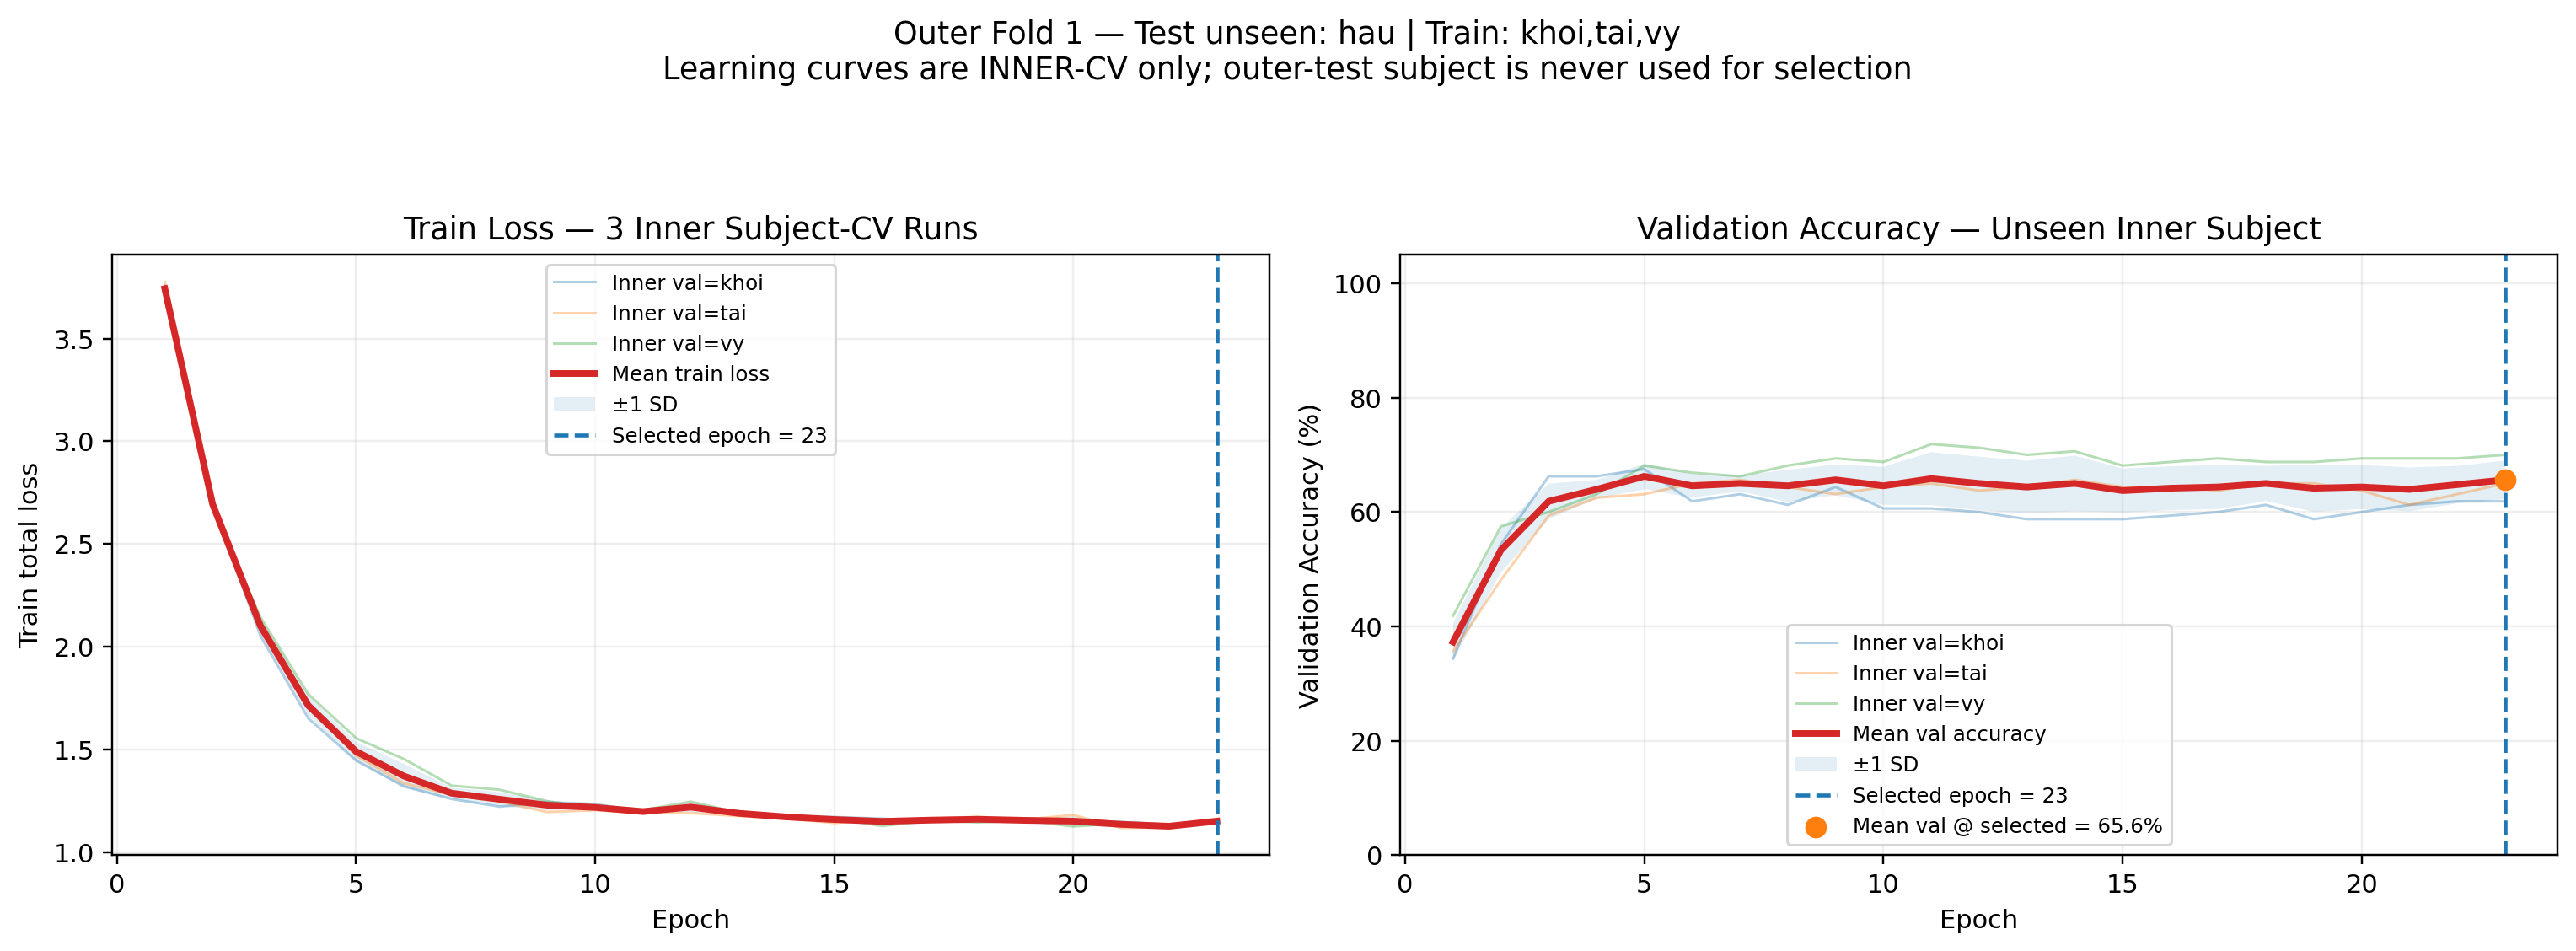

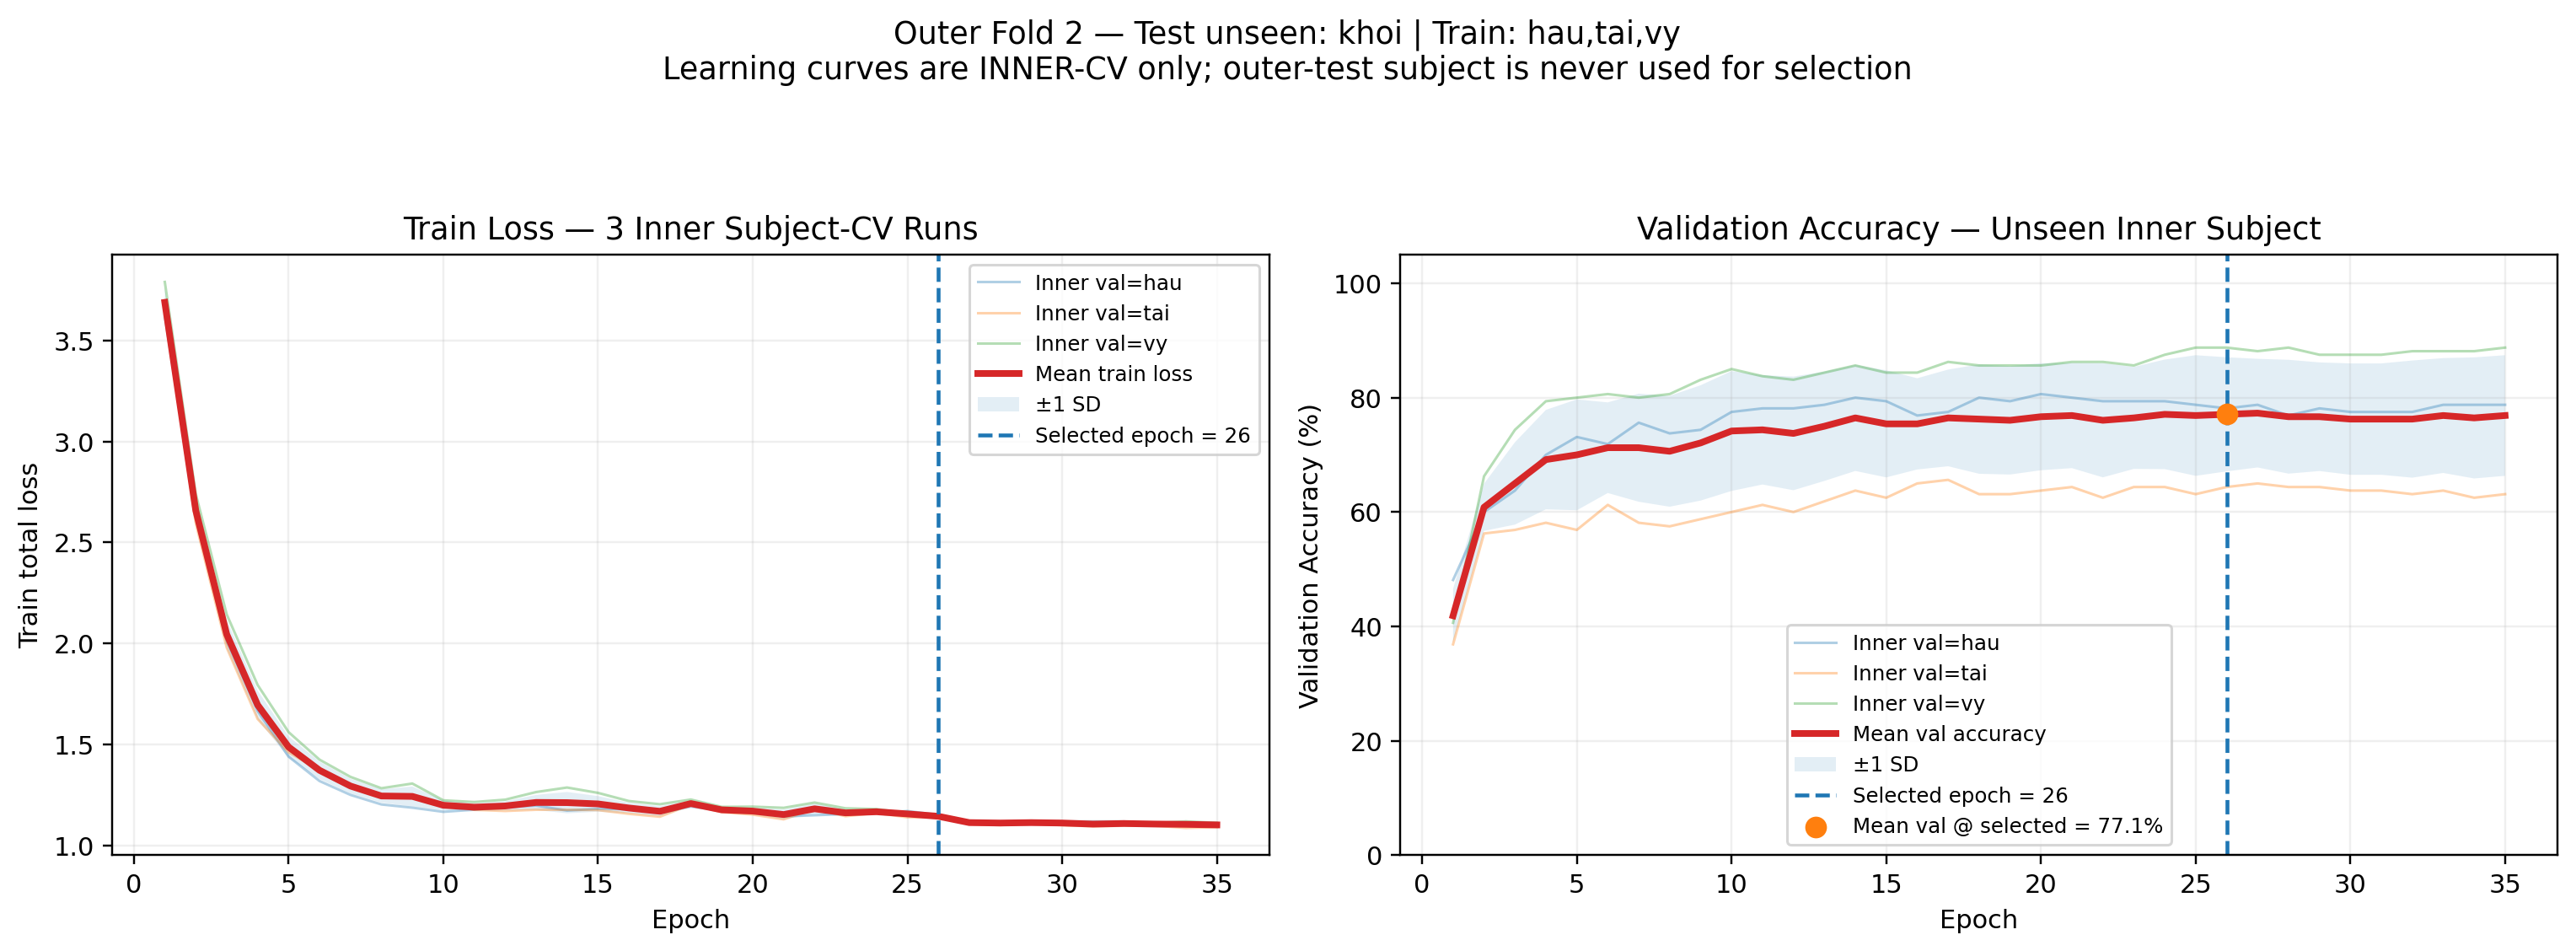

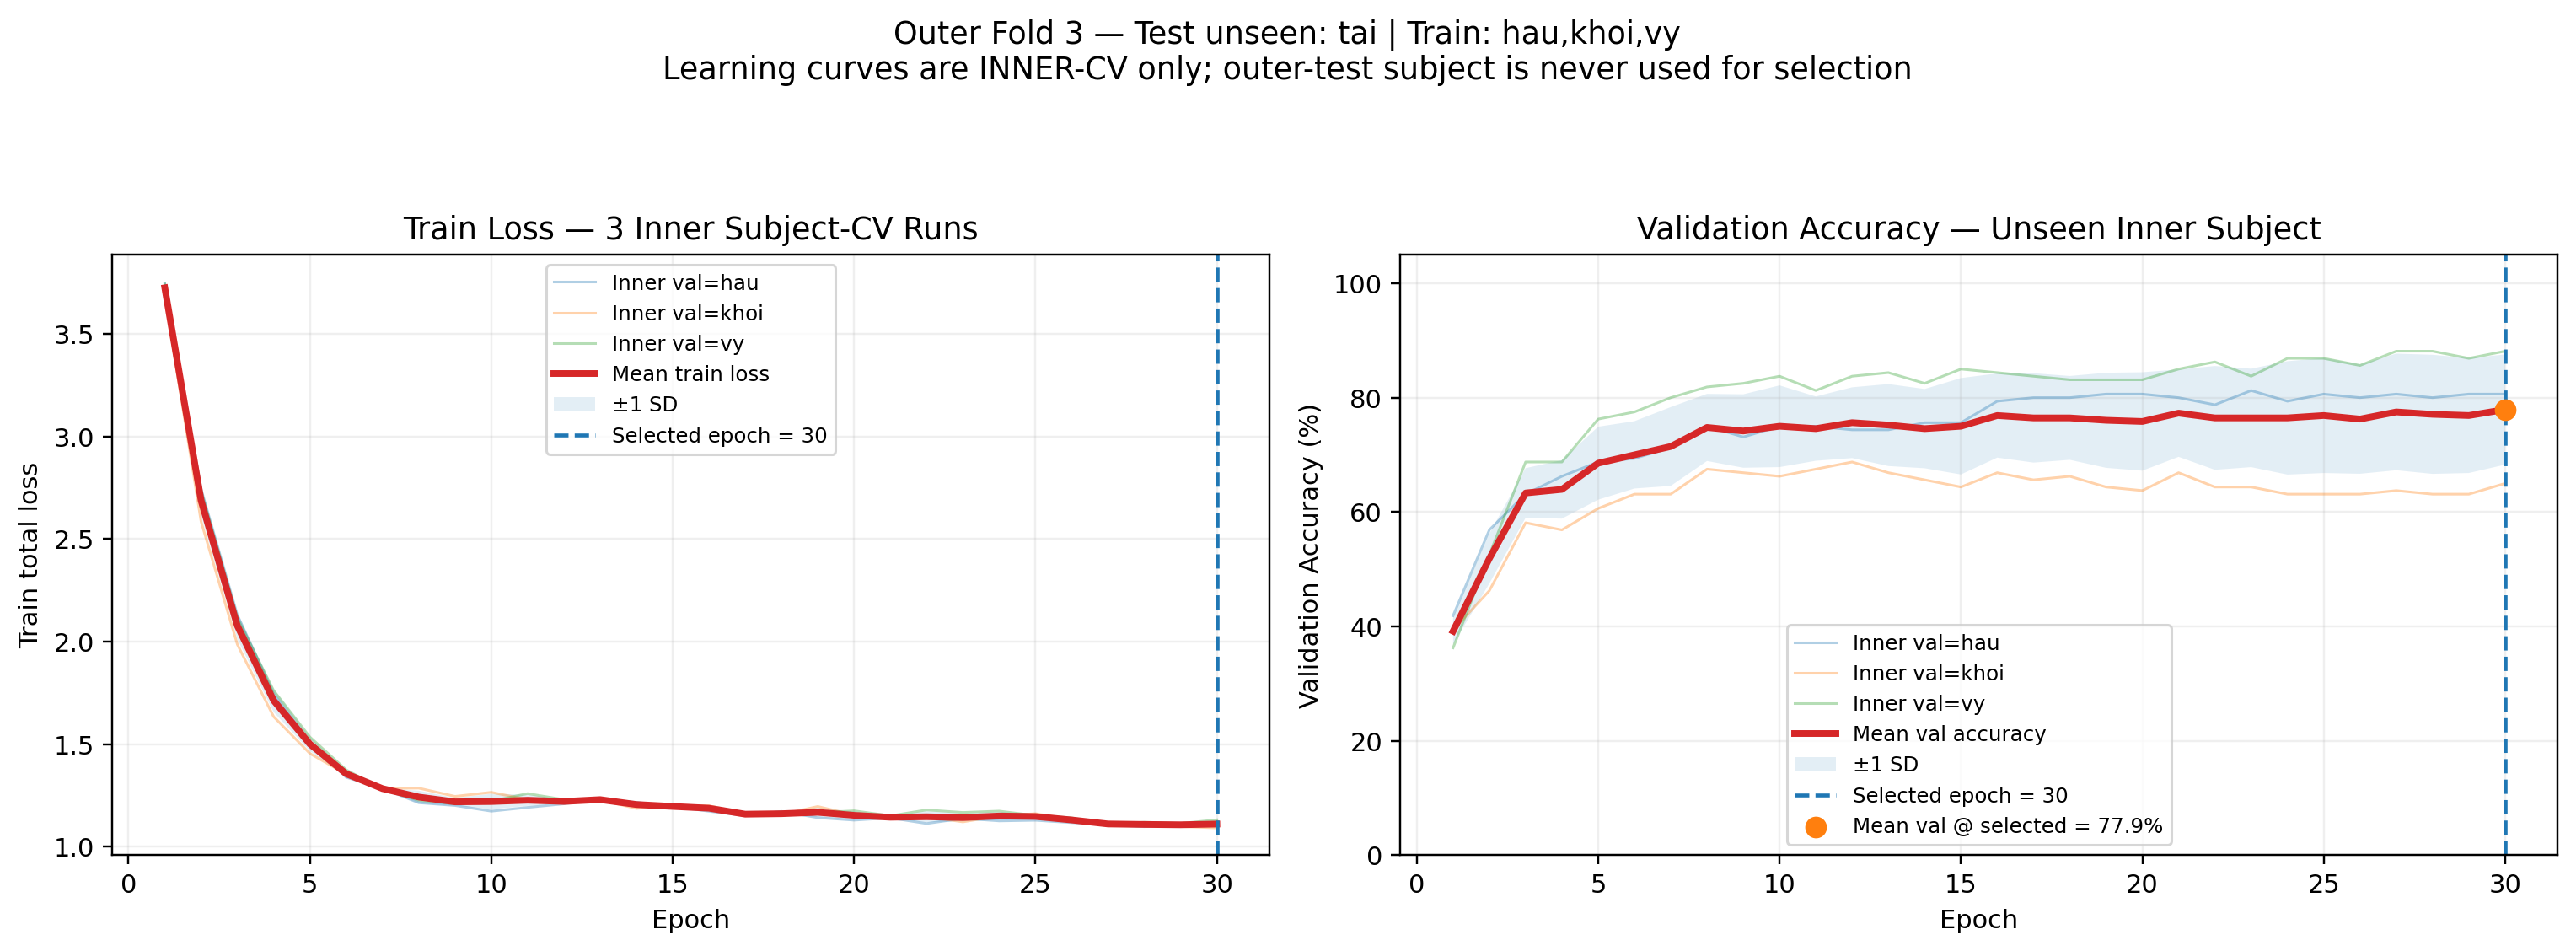

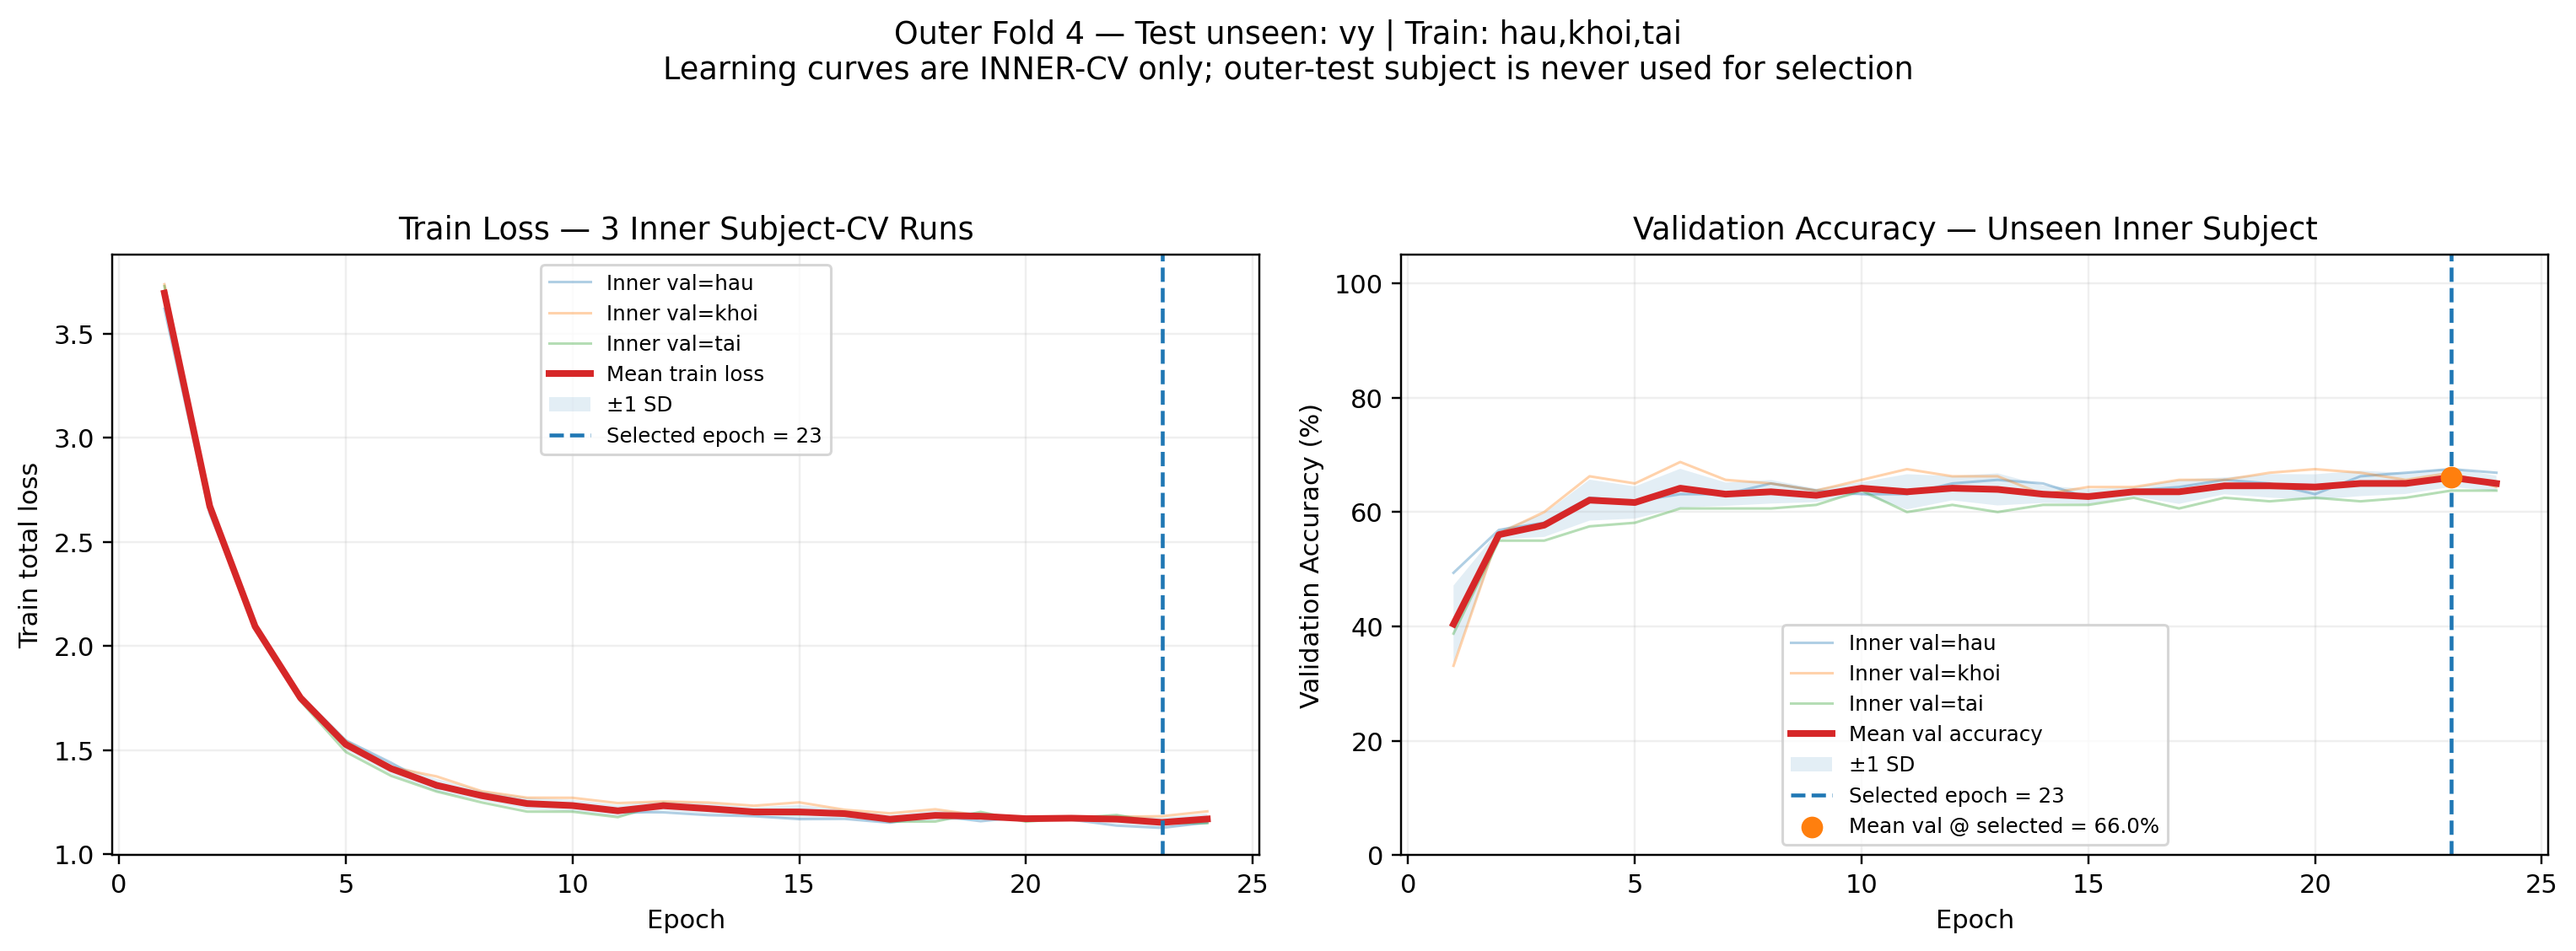

TRAIN LOSS & VALIDATION ACCURACY — SUMMARY


,fold,outer_test_person,outer_train_people,common_inner_epochs,selected_epoch,mean_train_loss_at_selected,mean_val_accuracy_at_selected,mean_val_accuracy_at_selected_%,best_raw_mean_val_accuracy,best_raw_mean_val_accuracy_%,inner_val_people
0,1,hau,"khoi,tai,vy",23,23,1.1526,0.6562,65.62,0.6625,66.25,"khoi,tai,vy"
1,2,khoi,"hau,tai,vy",35,26,1.1442,0.7708,77.08,0.7729,77.29,"hau,tai,vy"
2,3,tai,"hau,khoi,vy",30,30,1.1104,0.7792,77.92,0.7792,77.92,"hau,khoi,vy"
3,4,vy,"hau,khoi,tai",24,23,1.1519,0.6604,66.04,0.6604,66.04,"hau,khoi,tai"


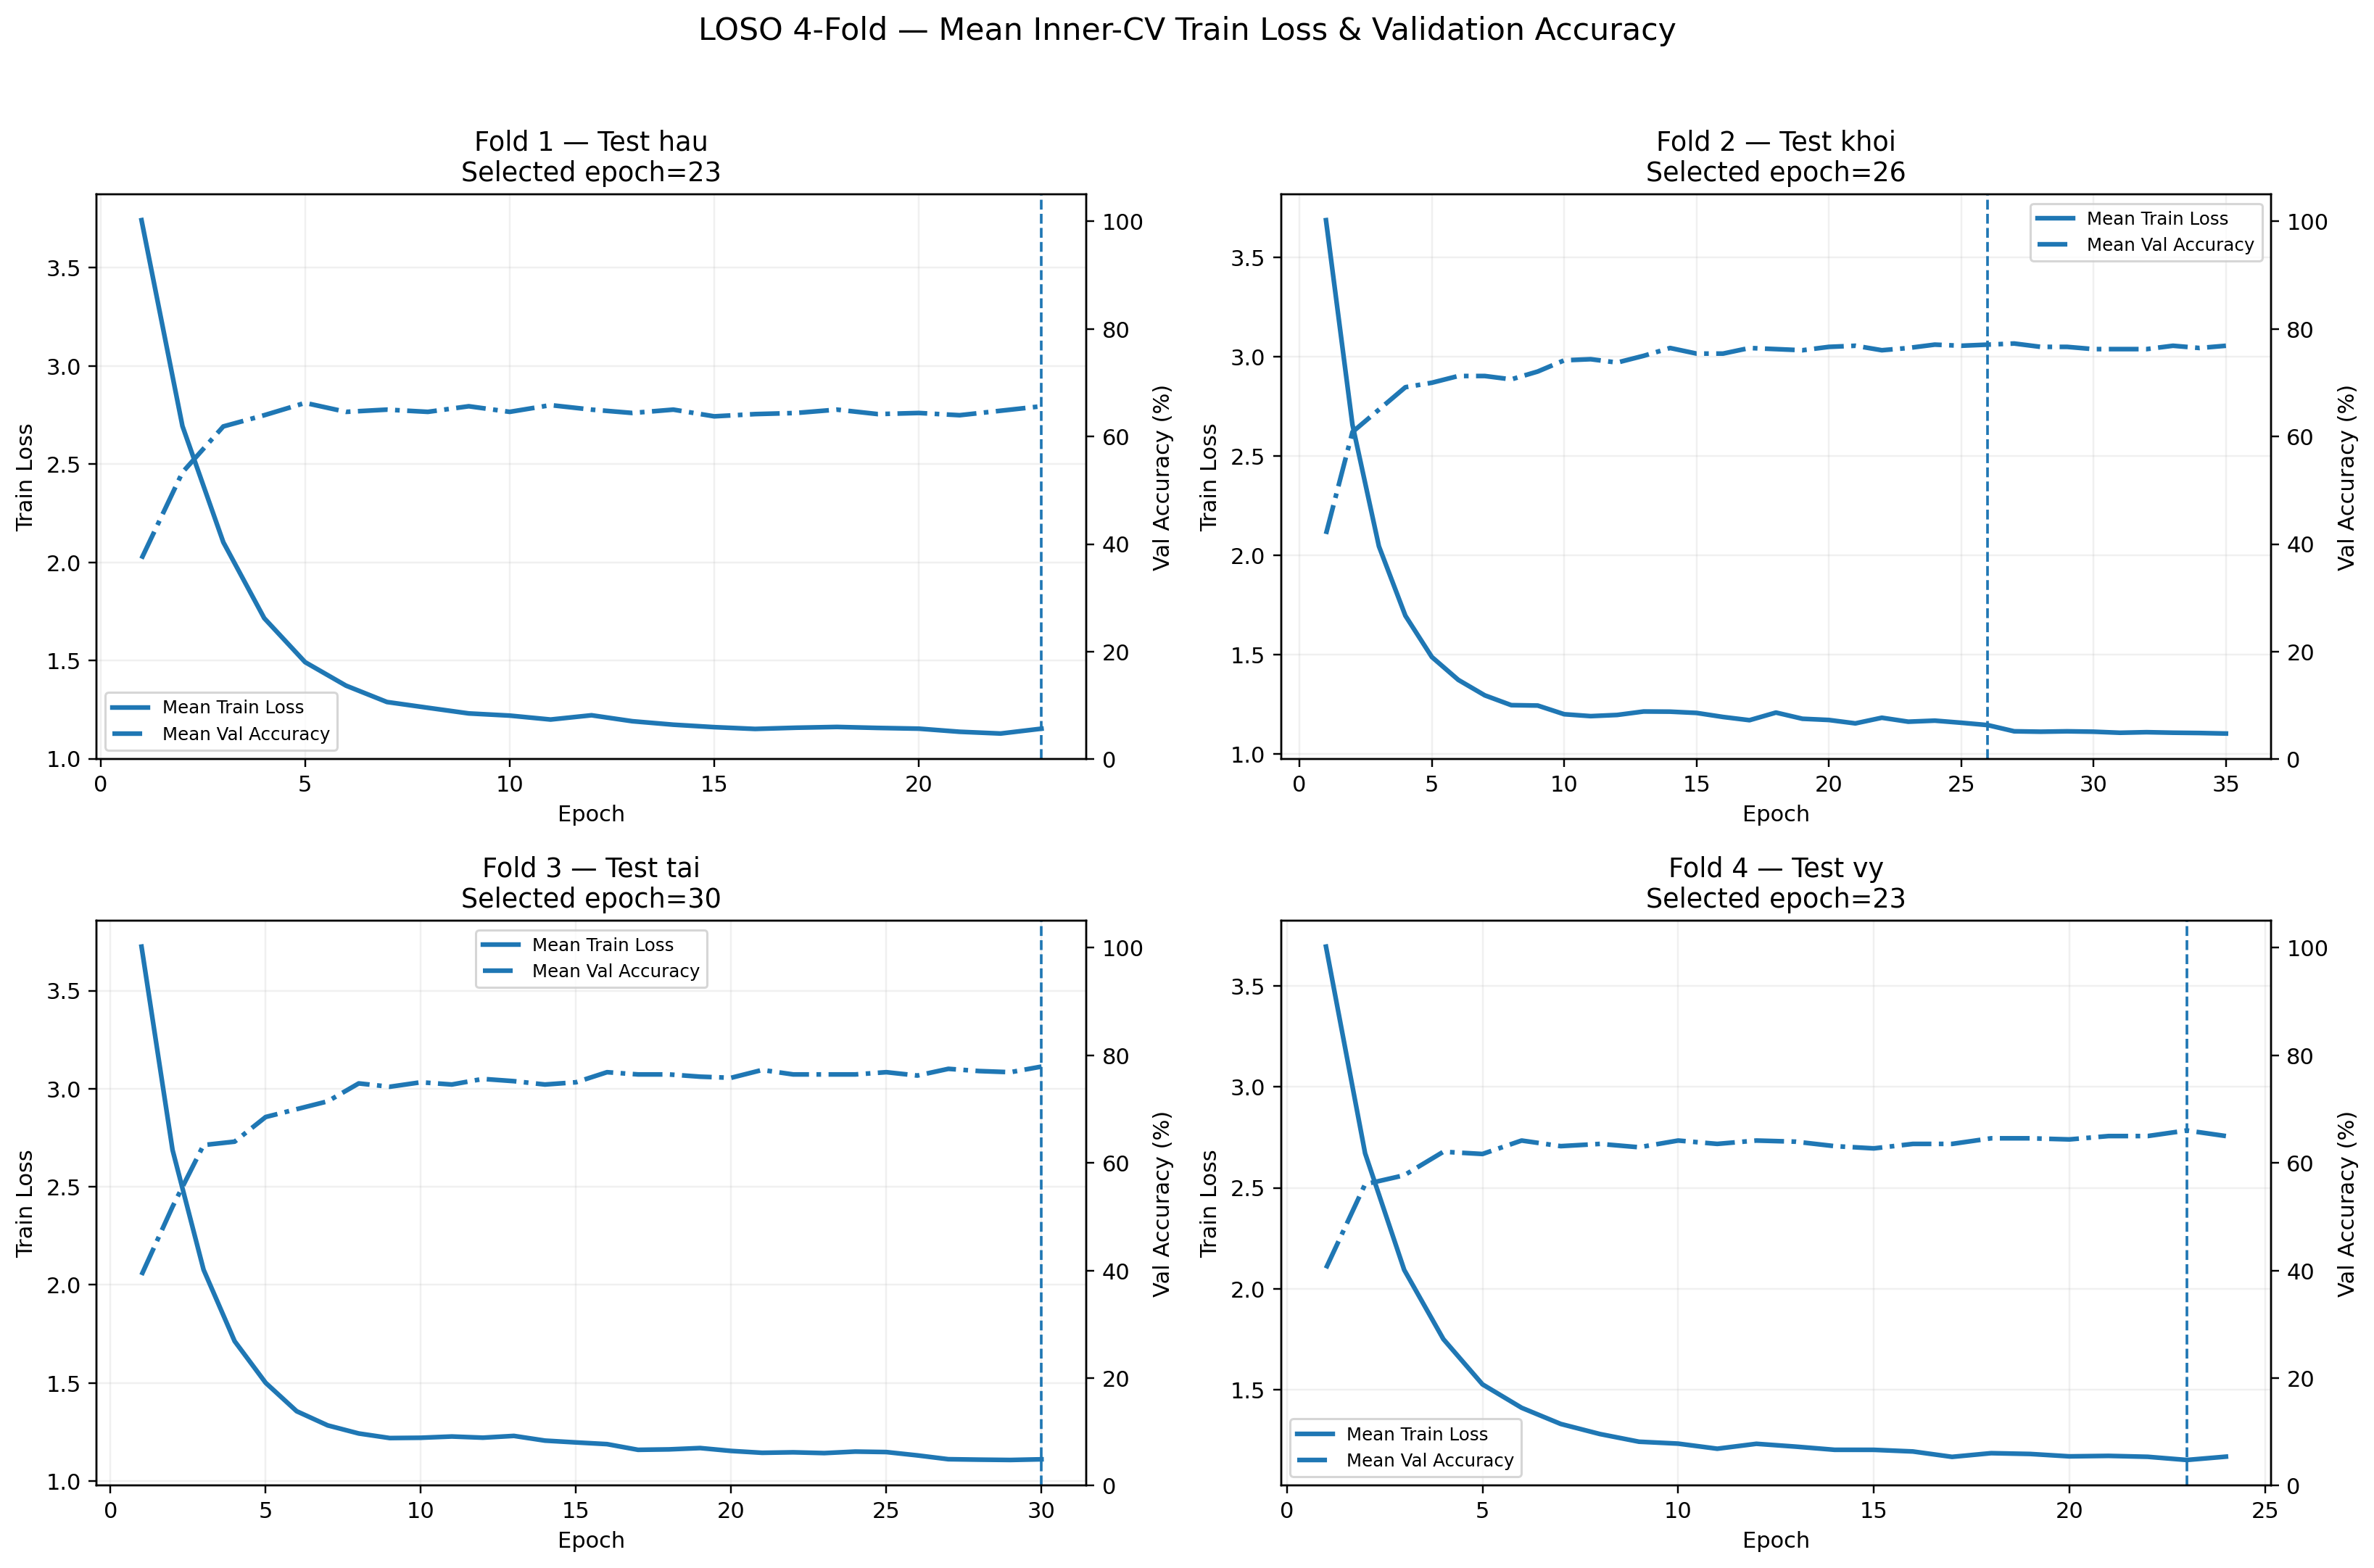


Đã lưu learning-curve images:
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_05_fold_1_test_hau_trainloss_valacc.png
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_05_fold_2_test_khoi_trainloss_valacc.png
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_05_fold_3_test_tai_trainloss_valacc.png
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_05_fold_4_test_vy_trainloss_valacc.png
 - E3PPP_LOSO_4FOLD_ARTIFACTS/EVAL_05_all_folds_trainloss_valacc.png

ZIP đã cập nhật Train Loss / Validation Accuracy: E3PPP_LOSO_4FOLD_3TRAIN_1TEST.zip


In [14]:
# ============================================================
# 9) TRAIN LOSS & VALIDATION ACCURACY THEO TỪNG OUTER FOLD
# ============================================================
# LƯU Ý:
# - Đây là INNER-CV curves bên trong mỗi outer fold.
# - Outer-test subject tuyệt đối không được dùng làm validation.
# - Mỗi fold có 3 inner runs: lần lượt 1/3 outer-train subjects làm validation.

from IPython.display import Image

if not fold_training_meta or any("inner" not in m for m in fold_training_meta.values()):
    raise RuntimeError(
        "Chưa có inner training history. Hãy chạy lại cell OUTER LOSO 4-FOLD trước khi chạy phần 9."
    )

training_curve_rows = []
training_curve_files = []

for fold_row in fold_df.sort_values("fold").itertuples():
    fold_no = int(fold_row.fold)
    test_person = str(fold_row.test_person)
    meta = fold_training_meta[test_person]
    inner_runs = meta["inner"]

    # Chỉ lấy đoạn epoch mà cả 3 inner folds đều còn dữ liệu,
    # đúng với logic _select_epoch_from_inner().
    common_len = min(len(x["history"]["val_acc"]) for x in inner_runs)
    epochs = np.arange(1, common_len + 1)

    train_loss_mat = np.stack([
        np.asarray(x["history"]["train_loss"][:common_len], dtype=float)
        for x in inner_runs
    ])
    val_acc_mat = np.stack([
        np.asarray(x["history"]["val_acc"][:common_len], dtype=float)
        for x in inner_runs
    ])

    mean_train_loss = train_loss_mat.mean(axis=0)
    std_train_loss = train_loss_mat.std(axis=0)
    mean_val_acc = val_acc_mat.mean(axis=0)
    std_val_acc = val_acc_mat.std(axis=0)

    selected_epoch = int(meta["final_epochs"])
    selected_idx = min(max(selected_epoch - 1, 0), common_len - 1)

    # --------------------------------------------------------
    # 1 ảnh riêng cho mỗi outer fold: Train Loss | Val Accuracy
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

    # ---- Train Loss ----
    ax = axes[0]
    for inner in inner_runs:
        curve = np.asarray(inner["history"]["train_loss"][:common_len], dtype=float)
        ax.plot(
            epochs, curve, linewidth=1.0, alpha=0.35,
            label=f"Inner val={inner['val_person']}"
        )

    ax.plot(epochs, mean_train_loss, linewidth=2.6, label="Mean train loss")
    ax.fill_between(
        epochs,
        mean_train_loss - std_train_loss,
        mean_train_loss + std_train_loss,
        alpha=0.12,
        label="±1 SD"
    )
    ax.axvline(selected_epoch, linestyle="--", linewidth=1.5,
               label=f"Selected epoch = {selected_epoch}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train total loss")
    ax.set_title("Train Loss — 3 Inner Subject-CV Runs")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

    # ---- Validation Accuracy ----
    ax = axes[1]
    for inner in inner_runs:
        curve = np.asarray(inner["history"]["val_acc"][:common_len], dtype=float) * 100.0
        ax.plot(
            epochs, curve, linewidth=1.0, alpha=0.35,
            label=f"Inner val={inner['val_person']}"
        )

    ax.plot(epochs, mean_val_acc * 100.0, linewidth=2.6, label="Mean val accuracy")
    ax.fill_between(
        epochs,
        (mean_val_acc - std_val_acc) * 100.0,
        (mean_val_acc + std_val_acc) * 100.0,
        alpha=0.12,
        label="±1 SD"
    )
    ax.axvline(selected_epoch, linestyle="--", linewidth=1.5,
               label=f"Selected epoch = {selected_epoch}")
    ax.scatter(
        [selected_epoch], [mean_val_acc[selected_idx] * 100.0],
        s=55, zorder=5,
        label=f"Mean val @ selected = {mean_val_acc[selected_idx]*100:.1f}%"
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.set_title("Validation Accuracy — Unseen Inner Subject")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

    fig.suptitle(
        f"Outer Fold {fold_no} — Test unseen: {test_person} | "
        f"Train: {fold_row.train_people}\n"
        f"Learning curves are INNER-CV only; outer-test subject is never used for selection",
        fontsize=12
    )
    fig.tight_layout(rect=[0, 0, 1, 0.91])

    out_png = CV_DIR / f"EVAL_05_fold_{fold_no}_test_{test_person}_trainloss_valacc.png"
    fig.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(out_png)))
    training_curve_files.append(str(out_png))

    training_curve_rows.append({
        "fold": fold_no,
        "outer_test_person": test_person,
        "outer_train_people": str(fold_row.train_people),
        "common_inner_epochs": int(common_len),
        "selected_epoch": selected_epoch,
        "mean_train_loss_at_selected": float(mean_train_loss[selected_idx]),
        "mean_val_accuracy_at_selected": float(mean_val_acc[selected_idx]),
        "mean_val_accuracy_at_selected_%": float(mean_val_acc[selected_idx] * 100.0),
        "best_raw_mean_val_accuracy": float(mean_val_acc.max()),
        "best_raw_mean_val_accuracy_%": float(mean_val_acc.max() * 100.0),
        "inner_val_people": ",".join(str(x["val_person"]) for x in inner_runs),
    })

training_curve_summary_df = pd.DataFrame(training_curve_rows).sort_values("fold").reset_index(drop=True)
training_curve_summary_df.to_csv(
    CV_DIR / "LOSO_4FOLD_trainloss_valacc_summary.csv", index=False
)

print("=" * 95)
print("TRAIN LOSS & VALIDATION ACCURACY — SUMMARY")
print("=" * 95)
display(training_curve_summary_df.round({
    "mean_train_loss_at_selected": 4,
    "mean_val_accuracy_at_selected": 4,
    "mean_val_accuracy_at_selected_%": 2,
    "best_raw_mean_val_accuracy": 4,
    "best_raw_mean_val_accuracy_%": 2,
}))

# ============================================================
# 9.2 ẢNH TỔNG HỢP 4 FOLD — mỗi fold dùng twin axes
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for ax, fold_row in zip(axes, fold_df.sort_values("fold").itertuples()):
    fold_no = int(fold_row.fold)
    test_person = str(fold_row.test_person)
    meta = fold_training_meta[test_person]
    inner_runs = meta["inner"]
    common_len = min(len(x["history"]["val_acc"]) for x in inner_runs)
    epochs = np.arange(1, common_len + 1)

    train_loss_mat = np.stack([
        np.asarray(x["history"]["train_loss"][:common_len], dtype=float)
        for x in inner_runs
    ])
    val_acc_mat = np.stack([
        np.asarray(x["history"]["val_acc"][:common_len], dtype=float)
        for x in inner_runs
    ])

    mean_train_loss = train_loss_mat.mean(axis=0)
    mean_val_acc = val_acc_mat.mean(axis=0) * 100.0
    selected_epoch = int(meta["final_epochs"])

    line1 = ax.plot(epochs, mean_train_loss, linewidth=2.1, label="Mean Train Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Loss")
    ax.grid(alpha=0.18)
    ax.axvline(selected_epoch, linestyle="--", linewidth=1.2)

    ax2 = ax.twinx()
    line2 = ax2.plot(epochs, mean_val_acc, linestyle="-.", linewidth=2.1,
                     label="Mean Val Accuracy")
    ax2.set_ylabel("Val Accuracy (%)")
    ax2.set_ylim(0, 105)

    lines = line1 + line2
    labels = [ln.get_label() for ln in lines]
    ax.legend(lines, labels, loc="best", fontsize=8)
    ax.set_title(
        f"Fold {fold_no} — Test {test_person}\nSelected epoch={selected_epoch}"
    )

fig.suptitle(
    "LOSO 4-Fold — Mean Inner-CV Train Loss & Validation Accuracy",
    fontsize=14
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
combined_png = CV_DIR / "EVAL_05_all_folds_trainloss_valacc.png"
fig.savefig(combined_png, dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(combined_png)))

print("\nĐã lưu learning-curve images:")
for p in training_curve_files:
    print(" -", p)
print(" -", combined_png)

# Rebuild ZIP để learning curves + history CSV cũng nằm trong artifacts package.
if "zip_path" in globals():
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for p in sorted(CV_DIR.rglob("*")):
            if p.is_file():
                zf.write(p, arcname=str(p.relative_to(CV_DIR)))
    print("\nZIP đã cập nhật Train Loss / Validation Accuracy:", zip_path)
